# Section 1 — The XOR Problem and nonlinear mixed selectivity

A core computation underlying flexible behaviour is **context-dependent processing**: responding to the same stimulus differently depending on the current context. In this section we build intuition as to what neural circuits need to do to solve it.

In [4]:
# ── Install dependencies (only needed on Colab) ──────────────────────────────
# !pip install pydantic plotly -q

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
%matplotlib inline

# ── Consistent tutorial style ─────────────────────────────────────────────
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'legend.fontsize': 9,
    'font.family': 'sans-serif',
})

# ── Shared colour palette ─────────────────────────────────────────────────
C_REWARD   = '#2ca02c'
C_NOREWARD = '#d62728'
C_PLANE_POS = '#2ca02c'
C_PLANE_NEG = '#d62728'


In [5]:
#@title Helper functions
# ══════════════════════════════════════════════════════════════════════════════
# HELPER CODE — Data generation & decoding functions
# These are bundled here so the notebook runs standalone on Colab.
# You do NOT need to read or modify this cell.
# ══════════════════════════════════════════════════════════════════════════════

# ── DataGenerator ─────────────────────────────────────────────────────────────
"""
XOR Task Data Generation Module with Complete Experiment Type Support
"""

from dataclasses import dataclass
from enum import Enum
from pathlib import Path
from typing import Tuple, Optional, Union, List, Dict, Any
import warnings

import numpy as np
import torch
import yaml
from numpy.typing import NDArray
from pydantic import BaseModel, model_validator, Field, validator
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader


class DataValidationError(Exception):
    """Custom exception for data validation errors."""
    pass


class EncodingMode(Enum):
    """Encoding modes for the XOR task."""
    ORTHOGONAL = "orthogonal"
    NON_ORTHOGONAL = "non-orthogonal"


class ExperimentType(Enum):
    """Available experiment types."""
    xor_basic = "xor_basic"
    xor_inactive_feat = "xor_inactive_feat"
    xor_colour_gen = "xor_colour_gen"
    and_basic = "and_basic"
    or_basic = "or_basic"
    abstract_binary = 'abstract_binary'
    abstract_binary_multitask = 'abstract_binary_multitask'


class TemporalParams(BaseModel):
    t_min: int = Field(-500, description="Start time in ms")
    t_max: int = Field(1500, description="End time in ms")
    dt: int = Field(20, description="Time step in ms")
    task_id_onset: float = Field(-200.0, description="Task ID signal onset")
    task_id_offset: float = Field(1000.0, description="Task ID signal offset")
    colour_onset: float = Field(0.0, description="Color stimulus onset")
    colour_offset: float = Field(1000.0, description="Color stimulus offset")
    shape_onset: float = Field(500.0, description="Shape stimulus onset")
    shape_offset: float = Field(1000.0, description="Shape stimulus offset")
    reward_onset: float = Field(1000.0, description="Reward onset")
    reward_offset: float = Field(1200.0, description="Reward offset")

    @model_validator(mode='after')
    def validate(self):
        """Validate temporal sequence is logical"""
        if self.t_min >= self.t_max:
            raise ValueError("t_min must be less than t_max")
        if self.task_id_onset >= self.task_id_offset:
            raise ValueError("task_id_onset must be before task_id_offset")
        if self.colour_onset >= self.colour_offset:
            raise ValueError("colour_onset must be before colour_offset")
        if self.shape_onset >= self.shape_offset:
            raise ValueError("shape_onset must be before shape_offset")
        if self.reward_onset >= self.reward_offset:
            raise ValueError("reward_onset must be before reward_offset")
        if self.dt <= 0:
            raise ValueError("dt must be positive")
        if (self.t_max - self.t_min) % self.dt != 0:
            raise ValueError(f"Time range ({self.t_max - self.t_min}) is not divisible by dt ({self.dt})")
        return self

def label_pattern(pattern):
    known_patterns = {
        (0,1,2,3): "NOT Color",
        (0,2,4,6): "NOT Shape",
        (0,1,4,5): "NOT Width",
        (0,1,6,7): "Color XNOR Shape",
        (0,2,5,7): "Color XNOR Width",
        (0,3,4,7): "Shape XNOR Width",
        (0,1,2,5): "Three-way: (NOT Color AND (NOT Shape OR Width)) OR (Color AND NOT Shape AND Width)",
    }
    pattern = tuple(sorted(pattern))
    return known_patterns.get(pattern, "Unknown pattern")

class DataGenerator:
    """Generator for XOR task data with temporal structure."""

    def __init__(
            self,
            config_path: Union[str, Path] = None,
            config: Optional[Dict[str, Any]] = None,
            task_indices: Optional[List] = None,
            seed: int = None,
            experiment_type: Optional[ExperimentType] = None,
            encoding_mode: Optional[EncodingMode] = None,
            device: Optional[str] = None,

    ):
        """
        Initialize the data generator.

        Args:
            config_path: Path to the configuration file
            experiment_type: Override experiment type from config if provided
            encoding_mode: Override encoding mode from config if provided
            device: Device to use for PyTorch tensors
        """
        self.config_path = Path(config_path) if config_path else None
        self.config = config
        if self.config is None:
            if self.config_path is None:
                raise ValueError("Either config or config_path must be provided")
            self.config = self._load_config(self.config_path)

        if seed is None:
            self.seed = self.config['reproducibility']['seed']
        else:
            self.seed = seed

        # Set experiment type from config if not provided
        if experiment_type is None:
            exp_type_str = self.config.get('data', {}).get('experiment_type')
            self.experiment_type = ExperimentType[exp_type_str]
        else:
            self.experiment_type = experiment_type



        # Set encoding mode from config if not provided
        if encoding_mode is None:
            encoding_str = self.config.get('data', {}).get('encoding_mode')
            self.encoding_mode = EncodingMode[encoding_str.upper()]
        else:
            self.encoding_mode = encoding_mode

        if task_indices is None:
            self.task_indices = self.config.get('data', {}).get('task_indices')

        else:
            self.task_indices = task_indices

        self.classification_index = self.task_indices[0]

        if device is None:
            device = self.config.get('hardware', {}).get('device')
            self.device = self._setup_device(device)
        else:
            self.device = torch.device(device)

        self.temporal_params = TemporalParams(**self.config.get("temporal", {}))
        self._validate_config()
        self.n_trials = self.config.get('data', {}).get('n_trials')
        self.batch_size = self.config.get('data', {}).get('batch_size')
        self.input_noise_std = self.config.get('data', {}).get('input_noise_std')
        self.num_workers = self.config.get('data', {}).get('num_workers')

        self.abstract_task_type = None
        if self.experiment_type == ExperimentType.abstract_binary and self.classification_index is not None:
            patterns = self._generate_abstract_binary_patterns()
            pattern = patterns[self.classification_index]
            self.abstract_task_type = self._get_abstract_task_type(pattern)

    def _get_abstract_task_type(self, pattern):
        task_types = {
            (0,1,2,3): "Color",
            (0,2,4,6): "Width",
            (0,1,4,5): "Shape",
            (0,1,6,7): "Color XOR Shape",
            (0,2,5,7): "Color XOR Width",
            (0,3,4,7): "Shape XOR Width",
            (0,1,2,5): "Three-way: (NOT Color AND NOTShape) OR (NOT Color AND NOT Width) OR (NOT Shape AND Width)",
        }
        return task_types.get(tuple(sorted(pattern)), "Unknown pattern")
    @staticmethod
    def _setup_device(device: Optional[str] = None) -> torch.device:
        """Set up the appropriate device for tensor operations."""
        if device is not None:
            return torch.device(device)

        if torch.cuda.is_available():
            return torch.device('cuda')
        elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
            return torch.device('mps')
        return torch.device('cpu')

    @staticmethod
    def _load_config(config_path: Union[str, Path]) -> dict:
        """Load configuration from file."""
        path = Path(config_path)
        if not path.exists():
            raise FileNotFoundError(f"Config file not found: {path}")

        with open(path) as f:
            config = yaml.safe_load(f)
        return config

    def _validate_config(self) -> None:
        """Validate configuration parameters."""
        self.temporal_params.validate()

        # Validate data parameters if present
        data_config = self.config.get('data', {})
        if 'n_trials' in data_config and data_config['n_trials'] <= 0:
            raise DataValidationError("n_trials must be positive")
        if 'input_noise_std' in data_config and data_config['input_noise_std'] < 0:
            raise DataValidationError("input_noise_std must be non-negative")
        if 'batch_size' in data_config and data_config['batch_size'] <= 0:
            raise DataValidationError("batch_size must be positive")
        if self.experiment_type == ExperimentType.abstract_binary and self.classification_index is None:
            raise DataValidationError("classification_index must be provided for abstract_binary experiment type")

    def get_data_params(self) -> dict:
        """Get data parameters from config with defaults."""
        data_config = self.config.get('data', {})
        return {
            'n_trials': data_config.get('n_trials'),
            'input_noise_std': data_config.get('input_noise_std'),
            'batch_size': data_config.get('batch_size'),
            'num_workers': data_config.get('num_workers')
        }
    def set_seed(self, seed: Optional[int] = None) -> None:
        """Set random seeds for reproducibility."""
        if seed is None:
            seed = np.random.choice(2 ** 32)

        np.random.seed(seed)
        torch.manual_seed(seed)

        if self.device.type == 'cuda':
            torch.cuda.manual_seed_all(seed)
            torch.backends.cudnn.deterministic = True
            torch.backends.cudnn.benchmark = False
        elif self.device.type == 'mps':
            pass  # MPS doesn't need special handling for seeds

    def generate_sequence_events(self) -> Tuple[NDArray, int, NDArray]:
        """Generate temporal sequence of events with task ID signals."""
        T = int((self.temporal_params.t_max - self.temporal_params.t_min) /
                self.temporal_params.dt)
        times = np.linspace(self.temporal_params.t_min,
                            self.temporal_params.t_max,
                            T + 1)[:-1]

        def _create_event_signal(onset: float, offset: float) -> NDArray:
            signal = np.zeros(T)
            start_idx = np.where(times >= onset)[0][0]
            end_idx = np.where(times >= offset)[0][0]
            signal[start_idx:end_idx] = 1
            return signal

        # Create base signals
        colour_on = _create_event_signal(self.temporal_params.colour_onset,
                                         self.temporal_params.colour_offset)
        shape_on = _create_event_signal(self.temporal_params.shape_onset,
                                        self.temporal_params.shape_offset)
        width_on = shape_on.copy()
        reward_on = _create_event_signal(self.temporal_params.reward_onset,
                                         self.temporal_params.reward_offset)

        # Only include task signals for multitask experiments
        if self.experiment_type == ExperimentType.abstract_binary_multitask:
            task_id_on = _create_event_signal(self.temporal_params.task_id_onset,
                                              self.temporal_params.task_id_offset)
            # Create task ID channels (one per task)
            task_signals = []
            for _ in self.task_indices:
                task_signals.append(task_id_on.copy())
            events = np.vstack(task_signals + [colour_on, shape_on, width_on, reward_on])
        else:
            # For single task, don't include task signals
            events = np.vstack([colour_on, shape_on, width_on, reward_on])

        return events, T, times

    def construct_design_matrix(self) -> NDArray:
        """Construct the design matrix for the XOR task."""
        use_orthogonal = self.encoding_mode == EncodingMode.ORTHOGONAL
        values = [-1, 1] if use_orthogonal else [0, 1]

        def _create_labels(pattern: List[bool], val1, val2) -> NDArray:
            return np.array([val1 if p else val2 for p in pattern])

        if self.experiment_type == ExperimentType.xor_basic:
            n_trials = 8
            pattern = [False] * 4 + [True] * 4
            colour_labels = _create_labels(pattern, values[1], values[0])
            shape_labels = _create_labels([False, False, True, True] * 2, values[1], values[0])
            width_labels = _create_labels([False, True] * 4, values[1], values[0])
            reward_labels = np.array([1, 1, 0, 0, 0, 0, 1, 1])

            return np.vstack([colour_labels, shape_labels, width_labels, reward_labels]).T

        elif self.experiment_type == ExperimentType.xor_colour_gen:
            n_trials = 16

            if use_orthogonal:
                # First color labels (active in trials 5-8: [-1,1], others: 0)
                colour1_labels = np.zeros(16)
                colour1_labels[:4] = -1  # baseline is -1 for orthogonal encoding
                colour1_labels[4:8] = 1  # active trials
                colour1_labels[8:] = 0  # when other color might be active

                # Second color labels (active in trials 13-16: [-1,1], others: 0)
                colour2_labels = np.zeros(16)
                colour2_labels[8:12] = -1  # baseline is -1 for orthogonal encoding
                colour2_labels[12:16] = 1  # active trials
                colour2_labels[:8] = 0  # when other color might be active

                # Shape and width use normal orthogonal encoding
                shape_labels = _create_labels([False, False, True, True] * 4, 1, -1)
                width_labels = _create_labels([False, True] * 8, 1, -1)

            else:
                # Non-orthogonal encoding - uses 0/1
                colour1_labels = np.zeros(16)
                colour1_labels[4:8] = 1

                colour2_labels = np.zeros(16)
                colour2_labels[12:16] = 1

                shape_labels = _create_labels([False, False, True, True] * 4, 1, 0)
                width_labels = _create_labels([False, True] * 8, 1, 0)

            # Reward pattern is the same for both encodings
            reward_labels = np.array([1, 1, 0, 0, 0, 0, 1, 1] * 2)

            return np.vstack([colour1_labels, colour2_labels, shape_labels, width_labels, reward_labels]).T

        elif self.experiment_type == ExperimentType.xor_inactive_feat:
            if use_orthogonal:
                # First color labels: use orthogonal encoding
                colour1_labels = np.zeros(8)
                colour1_labels[:4] = -1
                colour1_labels[4:] = 1

                # Second color labels: all zeros
                colour2_labels = np.zeros(8)

                # Shape and width use normal orthogonal encoding
                shape_labels = _create_labels([False, False, True, True] * 2, 1, -1)
                width_labels = _create_labels([False, True] * 4, 1, -1)

            else:
                # First color labels: use non-orthogonal encoding
                colour1_labels = np.zeros(8)
                colour1_labels[4:] = 1

                # Second color labels: all zeros
                colour2_labels = np.zeros(8)

                # Shape and width use normal non-orthogonal encoding
                shape_labels = _create_labels([False, False, True, True] * 2, 1, 0)
                width_labels = _create_labels([False, True] * 4, 1, 0)

            # Reward pattern is the same for both encodings
            reward_labels = np.array([1, 1, 0, 0, 0, 0, 1, 1])

            return np.vstack([colour1_labels, colour2_labels, shape_labels, width_labels, reward_labels]).T

        elif self.experiment_type == ExperimentType.and_basic:
            n_trials = 8
            pattern = [False] * 4 + [True] * 4
            colour_labels = _create_labels(pattern, values[1], values[0])
            shape_labels = _create_labels([False, False, True, True] * 2, values[1], values[0])
            width_labels = _create_labels([False, True] * 4, values[1], values[0])
            # AND rule: reward only when all inputs are high
            reward_labels = np.array([0, 0, 0, 0, 0, 0, 1, 1])

            return np.vstack([colour_labels, shape_labels, width_labels, reward_labels]).T

        elif self.experiment_type == ExperimentType.or_basic:
            n_trials = 8
            pattern = [False] * 4 + [True] * 4
            colour_labels = _create_labels(pattern, values[1], values[0])
            shape_labels = _create_labels([False, False, True, True] * 2, values[1], values[0])
            width_labels = _create_labels([False, True] * 4, values[1], values[0])
            # AND rule: reward only when all inputs are high
            reward_labels = np.array([1, 1, 1, 1, 1, 1, 0, 0])

            return np.vstack([colour_labels, shape_labels, width_labels, reward_labels]).T

        elif self.experiment_type == ExperimentType.abstract_binary:
            # Generate base patterns for inputs
            pattern = [False] * 4 + [True] * 4
            colour_labels = _create_labels(pattern, values[1], values[0])
            shape_labels = _create_labels([False, False, True, True] * 2, values[1], values[0])
            width_labels = _create_labels([False, True] * 4, values[1], values[0])

            # Get reward pattern based on classification index
            patterns = self._generate_abstract_binary_patterns()
            reward_pattern = [1 if i in patterns[self.classification_index] else 0
                              for i in range(8)]
            reward_labels = np.array(reward_pattern)

            return np.vstack([colour_labels, shape_labels, width_labels, reward_labels]).T

        elif self.experiment_type == ExperimentType.abstract_binary_multitask:

            design_matrix_combined = []
            for i_task in range(len(self.task_indices)):
                # Create task ID labels (one-hot encoding across tasks)
                task_id_labels = []
                for j in range(len(self.task_indices)):
                    # 1 for current task, 0 (or -1) for other tasks based on encoding mode
                    task_labels = np.full(8, values[0])  # Fill with low value (0 or -1)
                    if i_task == j:
                        task_labels = np.full(8, values[1])  # Fill with high value (1)
                    task_id_labels.append(task_labels)

                # Generate base patterns for inputs
                pattern = [False] * 4 + [True] * 4
                colour_labels = _create_labels(pattern, values[1], values[0])
                shape_labels = _create_labels([False, False, True, True] * 2, values[1], values[0])
                width_labels = _create_labels([False, True] * 4, values[1], values[0])

                # Get reward pattern based on classification index
                patterns = self._generate_abstract_binary_patterns()
                reward_pattern = [1 if i in patterns[self.task_indices[i_task]] else 0
                                  for i in range(8)]
                reward_labels = np.array(reward_pattern)

                # Stack all signals including task IDs
                design_matrix = np.vstack(task_id_labels + [colour_labels, shape_labels, width_labels, reward_labels]).T
                design_matrix_combined.append(design_matrix)

            # Combine all matrices vertically
            design_matrix = np.vstack(design_matrix_combined)

            return design_matrix

        else:
            raise ValueError(f"Unknown experiment type: {self.experiment_type}")

    def _generate_abstract_binary_patterns(self):
        """Generate all possible binary classifications for 8 conditions."""
        import itertools

        # Generate all possible reward patterns (35 unique patterns)
        n_conditions = 8
        n_rewards = 4
        patterns = []
        seen = set()

        for pattern in itertools.combinations(range(n_conditions), n_rewards):
            inverse = tuple(sorted(set(range(n_conditions)) - set(pattern)))
            pattern_key = tuple(sorted([pattern, inverse]))

            if pattern_key not in seen:
                patterns.append(list(pattern))
                seen.add(pattern_key)

        return patterns

    def generate_data(
        self,
        n_trials: int = None,
        input_noise_std: float = None,
        return_trial_types: bool = False,
        return_times: bool = False,
    ) -> Tuple[torch.Tensor, ...]:
        """Generate XOR task data."""
        design_matrix = self.construct_design_matrix()
        event_sequence, T, times = self.generate_sequence_events()
        n_trial_types = design_matrix.shape[0]

        if n_trials is None:
            n_trials = self.n_trials
        if input_noise_std is None:
            input_noise_std = self.input_noise_std

        if n_trials % n_trial_types != 0:
            raise DataValidationError(f"n_trials must be divisible by {n_trial_types}")

        # Generate base patterns
        X_type = np.zeros((n_trial_types, T, design_matrix.shape[1]-1))
        y_type = np.zeros((n_trial_types, T, 2))

        for trial_type in range(n_trial_types):
            # Input patterns
            X_type[trial_type] = (event_sequence[:-1] *
                                design_matrix[trial_type, :-1, None]).T

            # Output patterns
            reward_val = design_matrix[trial_type, -1]
            y_type[trial_type, :, 0] = event_sequence[-1] * reward_val
            y_type[trial_type, :, 1] = event_sequence[-1] * (not reward_val)


        # Replicate patterns
        repeats = n_trials // n_trial_types
        X = np.tile(X_type, (repeats, 1, 1))
        y = np.tile(y_type, (repeats, 1, 1))
        trial_types = np.tile(np.arange(n_trial_types), repeats)

        # Add noise if specified
        if input_noise_std > 0:
            X += np.random.randn(*X.shape) * input_noise_std

        # Convert to PyTorch tensors
        X = torch.tensor(X, dtype=torch.float32, device=self.device)
        y = torch.tensor(y, dtype=torch.float32, device=self.device)

        # Return requested outputs
        outputs = [X, y]
        if return_trial_types:
            outputs.append(trial_types)
        if return_times:
            outputs.append(times)

        return tuple(outputs)

    def prepare_dataloader(
            self,
            n_trials: Optional[int] = None,
            batch_size: Optional[int] = None,
            input_noise_std: Optional[float] = None,
            shuffle: bool = True,
            num_workers: Optional[int] = None,
            return_trial_types: bool = False,
            return_task_labels: bool = False
    ) -> Dict[str, Union[torch.utils.data.DataLoader, np.ndarray]]:
        """
        Prepare a DataLoader with freshly generated data.
        Uses parameters from config file if not explicitly provided.
        """
        # Get parameters from config if not provided
        n_trials = n_trials if n_trials is not None else self.n_trials
        batch_size = batch_size if batch_size is not None else self.batch_size
        input_noise_std = input_noise_std if input_noise_std is not None else self.input_noise_std
        num_workers = num_workers if num_workers is not None else self.num_workers

        # Generate data - always get trial_types if we need task_labels
        if return_trial_types or (
                self.experiment_type == ExperimentType.abstract_binary_multitask):
            X, y, trial_types = self.generate_data(
                n_trials=n_trials,
                input_noise_std=input_noise_std,
                return_trial_types=True,
                return_times=False
            )
        else:
            X, y = self.generate_data(
                n_trials=n_trials,
                input_noise_std=input_noise_std,
                return_trial_types=False,
                return_times=False
            )
            trial_types = None

        # Create task labels from trial types for multitask setup
        if self.experiment_type == ExperimentType.abstract_binary_multitask:
            # Each task has 8 trials, determine which task a trial belongs to
            task_positions = trial_types // 8  # Position in task_indices list

            # Map positions to actual task indices from task_indices
            task_values = np.array(self.task_indices)[task_positions]

            # Convert to tensor with same device as X
            task_labels = torch.tensor(task_values, device=X.device)
            dataset = TensorDataset(X, y, task_labels)
        else:
            dataset = TensorDataset(X, y)

        # Create DataLoader
        dataloader = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            drop_last=True,
            num_workers=num_workers,
        )

        # Prepare result

        if return_trial_types:
            result = {'dataloader': dataloader}
            result['trial_types'] = trial_types
        if self.experiment_type == ExperimentType.abstract_binary_multitask and return_task_labels:
            result = {'dataloader': dataloader}
            result['task_labels'] = task_labels
            result['trial_types'] = trial_types
        else:
            result = dataloader

        return result

    def generate_mask(
            self,
            trial_type: int = 0,
            plot_mask: bool = False,
            mask_format: str = 'weights',
    ) -> NDArray:
        """
        Generate temporal mask for the loss function.
        For multi-task setting, generates mask using the first task's pattern.
        """
        # Temporarily set classification index to first task
        original_index = self.classification_index
        self.classification_index = self.task_indices[0]

        # Generate data using parent method
        X, y, trial_types, times = self.generate_data(
            n_trials=16,
            input_noise_std=0.0,
            return_trial_types=True,
            return_times=True
        )

        # Restore original classification index
        self.classification_index = original_index

        # Find first rewarded trial
        trial_idx = np.where((y.cpu()[:, :, 0] > 0).any(axis=1))[0][0]

        if mask_format == 'bool':
            mask = y[trial_idx, :, 0] > 0
        elif mask_format == 'weights':
            mask = y[trial_idx, :, 0]
        else:
            raise DataValidationError("Mask format not recognised")

        if not mask.any():
            raise DataValidationError(f"Generated mask contains only zeros")

        if plot_mask:
            plt.figure(figsize=(12, 3))
            plt.plot(times, mask.numpy().astype(float), 'k-', linewidth=2, label=f'Mask (Trial {trial_type})')
            plt.fill_between(times, 0, mask.numpy().astype(float), alpha=0.2, color='gray')
            plt.title('Temporal mask', pad=10)
            plt.xlabel('Time (ms)', labelpad=10)
            plt.ylabel('Value', labelpad=10)
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.ylim(-0.1, 1.1)
            plt.tight_layout()
            plt.show()

        if mask_format == 'weights':
            seq_len = y.shape[1]
            mask = mask.view(1, seq_len, 1)
            mask = mask.repeat(self.batch_size, 1, y.shape[-1])

        return mask

    # ===== Main Visualization Methods =====
    def plot_design_matrices(self) -> None:
        """Plot design matrix for the current encoding scheme."""
        feature_names = self._get_feature_names()

        fig, ax = plt.subplots(figsize=(8, 8))
        design_matrix = self.construct_design_matrix()

        sns.heatmap(design_matrix, ax=ax, cmap='coolwarm', center=0,
                    xticklabels=feature_names[:design_matrix.shape[1]],
                    yticklabels=[f'Trial {i + 1}' for i in range(design_matrix.shape[0])],
                    annot=True, fmt='.1f')
        ax.set_title(f'{self.encoding_mode.value.title()} Encoding\n{self.experiment_type.name}')
        ax.set_xlabel('Features')
        ax.set_ylabel('Trial Types')

        plt.tight_layout()
        plt.show()

        #self._print_design_matrix_explanation()

    def plot_event_sequence(self) -> None:
        """Plot event sequence."""
        events, T, times = self.generate_sequence_events()
        event_names = self._get_event_names()

        # Calculate figure size based on number of events
        width = 12
        height = max(4, len(event_names) * 0.8)  # Adjust height based on number of events

        fig, ax = plt.subplots(figsize=(width, height))

        spacing = 1.5
        for i, (event, name) in enumerate(zip(events, event_names)):
            ax.plot(times, event + i * spacing, label=name, linewidth=2)

        ax.set_xlabel('Time (ms)', labelpad=10)
        ax.set_ylabel('Event', labelpad=10)
        ax.set_title(f'Event Sequence - {self.experiment_type.name}', pad=20)

        # Adjust y-axis to show all events clearly
        ax.set_yticks([i * spacing for i in range(len(event_names))])
        ax.set_yticklabels(event_names)

        # Add grid and legend
        ax.grid(True, alpha=0.3)
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

        plt.tight_layout()
        plt.show()

    def plot_trial_types(self, n_trials: Optional[int] = None) -> None:
        """Plot all trial types."""
        if n_trials is None:
            if self.experiment_type == ExperimentType.xor_colour_gen:
                n_trials = 240
            elif self.experiment_type == ExperimentType.abstract_binary_multitask:
                n_trials = len(self.task_indices) * 8 * 10  # 10 repeats per trial type per task
            else:
                n_trials = 480

        X, y, trial_types, times = self.generate_data(
            n_trials=n_trials,
            input_noise_std=self.input_noise_std,
            return_trial_types=True,
            return_times=True
        )

        # Determine grid layout based on experiment type
        if self.experiment_type == ExperimentType.xor_colour_gen:
            n_rows, n_cols = 4, 4
        elif self.experiment_type == ExperimentType.abstract_binary_multitask:
            n_rows = len(self.task_indices)
            n_cols = 8  # 8 trial types per task
        else:
            n_rows, n_cols = 2, 4

        # Calculate figure size based on grid
        width = min(30, n_cols * 4)  # Cap maximum width, increased for multitask
        height = min(30, n_rows * 6)  # Cap maximum height, increased for multitask

        # Create figure with GridSpec
        fig = plt.figure(figsize=(width + 2, height))  # Add extra width for legend
        gs = fig.add_gridspec(n_rows, n_cols)

        unique_types = np.sort(np.unique(trial_types))
        input_names = self._get_input_names()
        n_tasks = len(self.task_indices) if self.experiment_type == ExperimentType.abstract_binary_multitask else 0

        # Skip task ID channels in plotting
        if self.experiment_type == ExperimentType.abstract_binary_multitask:
            input_names = input_names[n_tasks:]  # Skip task ID channels

        # Define colors for regular inputs
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(input_names)]

        # Create a single legend axis
        legend_ax = fig.add_axes([0.92, 0.1, 0.05, 0.8])
        legend_ax.axis('off')

        # Create legend handles
        legend_lines = [plt.Line2D([0], [0], color=color, label=name)
                        for color, name in zip(colors, input_names)]
        legend_lines.append(plt.Line2D([0], [0], color='gray', alpha=0.2,
                                       linewidth=10, label='Reward'))

        # Add legend to the separate axis
        legend_ax.legend(handles=legend_lines, loc='center left')

        for trial_type in unique_types:
            trial_idx = np.where(trial_types == trial_type)[0][0]
            row = trial_type // n_cols
            col = trial_type % n_cols
            ax = fig.add_subplot(gs[row, col])

            # Plot inputs (skip task ID channels for plotting)
            X_plot = X[trial_idx, :, n_tasks:] if self.experiment_type == ExperimentType.abstract_binary_multitask else \
            X[trial_idx]
            for i, (name, color) in enumerate(zip(input_names, colors)):
                ax.plot(times, X_plot[:, i].cpu().numpy(),
                        color=color, linewidth=2)

            # Add reward as shaded area
            reward = y[trial_idx, :, 0].cpu().numpy()
            ax.fill_between(times, 0, reward, alpha=0.2, color='gray')

            # Add task indication for multitask
            if self.experiment_type == ExperimentType.abstract_binary_multitask:
                task_idx = trial_type // 8  # 8 trials per task
                ax.set_title(f'Task {self.task_indices[task_idx]}\nTrial {trial_type % 8}')
            else:
                ax.set_title(f'Trial Type {trial_type}')

            ax.grid(True, alpha=0.3)

            # Add labels for outer plots
            if trial_type >= (n_rows - 1) * n_cols:
                ax.set_xlabel('Time (ms)')
            if trial_type % n_cols == 0:
                ax.set_ylabel('Input/Output')

            # Set consistent y-axis limits across all subplots
            ax.set_ylim(-1.5, 1.5)

        plt.suptitle(f'All Trial Types in {self.experiment_type.name}',
                     fontsize=16, y=0.95)

        # Use constrained layout instead of tight_layout
        plt.subplots_adjust(right=0.9)  # Make room for legend

        plt.show()

        self._print_trial_summary(X, y, trial_types, input_names)

    def plot_experiment_summary(self) -> None:
        print(f"\n{'=' * 50}\nAnalszing {self.experiment_type.name} {self.abstract_task_type}\n{'=' * 50}")

        print("\nDesign Matrices:")
        self.plot_design_matrices()

        print("\nEvent Sequence:")
        self.plot_event_sequence()

        print("\nTrial Types:")
        self.plot_trial_types()

    def _get_feature_names(self) -> List[str]:
        """Get feature names based on experiment type."""
        if self.experiment_type == ExperimentType.xor_basic:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.xor_colour_gen:
            return ['Color 1', 'Color 2', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.xor_inactive_feat:
            return ['Color 1', 'Color 2', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.and_basic:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.or_basic:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.abstract_binary:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.abstract_binary_multitask:
            # Add task ID channels (one per task) to the feature names
            task_channels = [f'Task_{i}' for i in range(len(self.task_indices))]
            return task_channels + ['Color', 'Shape', 'Width', 'Reward']

    def _get_event_names(self) -> List[str]:
        """Get event names based on experiment type."""
        if self.experiment_type == ExperimentType.xor_basic:
            return ['Colour', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.xor_inactive_feat:
            return ['Colour 1', 'Colour 2', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.xor_inactive_feat:
            return ['Colour 1', 'Colour 2', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.and_basic:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.or_basic:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.abstract_binary:
            return ['Color', 'Shape', 'Width', 'Reward']
        elif self.experiment_type == ExperimentType.abstract_binary_multitask:
            # Add task ID channels (one per task) to the feature names
            task_channels = [f'Task_{i}' for i in range(len(self.task_indices))]
            return task_channels + ['Color', 'Shape', 'Width', 'Reward']

    def _get_input_names(self) -> List[str]:
        """Get input names based on experiment type."""
        if self.experiment_type == ExperimentType.xor_basic:
            return ['Colour', 'Shape', 'Width']
        elif self.experiment_type == ExperimentType.xor_inactive_feat:
            return ['Colour 1', 'Colour 2', 'Shape', 'Width']
        elif self.experiment_type == ExperimentType.xor_colour_gen:
            return ['Colour 1', 'Colour 2', 'Shape', 'Width']
        elif self.experiment_type == ExperimentType.and_basic:
            return ['Colour', 'Shape', 'Width']
        elif self.experiment_type == ExperimentType.or_basic:
            return ['Colour', 'Shape', 'Width']
        elif self.experiment_type == ExperimentType.abstract_binary:
            return ['Colour', 'Shape', 'Width']
        elif self.experiment_type == ExperimentType.abstract_binary_multitask:
            # Add task ID channels (one per task) to the feature names
            task_channels = [f'Task_{i}' for i in range(len(self.task_indices))]
            return task_channels + ['Color', 'Shape', 'Width']

    def _get_plot_grid_size(self) -> tuple:
        """Get plot grid size based on experiment type."""
        if self.experiment_type == ExperimentType.xor_colour_gen:
            return 4, 4
        return 2, 4

    # ===== Helper Methods for Plotting =====
    def _plot_trial_grid(self, fig, gs, X, y, times, trial_types,
                         unique_types, input_names, n_rows, n_cols):
        """Helper method to plot trial grid."""
        colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'][:len(input_names)]

        for trial_type in unique_types:
            trial_idx = np.where(trial_types == trial_type)[0][0]
            ax = fig.add_subplot(gs[trial_type // n_cols, trial_type % n_cols])

            # Plot inputs
            for i, (name, color) in enumerate(zip(input_names, colors)):
                ax.plot(times, X[trial_idx, :, i].cpu().numpy(),
                        label=name, color=color, linewidth=2)

            # Add reward as shaded area
            reward = y[trial_idx, :, 0].cpu().numpy()
            ax.fill_between(times, 0, reward, alpha=0.2, color='gray', label='Reward')

            ax.set_title(f'Trial Type {trial_type}')
            ax.grid(True, alpha=0.3)

            if trial_type == 0:
                ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            if trial_type >= (n_rows - 1) * n_cols:
                ax.set_xlabel('Time (ms)')
            if trial_type % n_cols == 0:
                ax.set_ylabel('Input/Output')

    # ===== Helper Methods for Printing Information =====
    # def _print_design_matrix_explanation(self):
    #     """Print explanation of design matrix structure."""
    #     n_trials = 8 if self.experiment_type in [ExperimentType.xor_basic, ExperimentType.xor_inactive_feat] else 16
    #     print(f"\nDesign Matrix Structure for {self.experiment_type.name}:")
    #     print(f"- {n_trials} trial types (rows)")
    #     print("- Features (columns):")
    #     if self.experiment_type == ExperimentType.xor_basic:
    #         print("  * Color: Single color channel")
    #     elif self.experiment_type == ExperimentType.xor_inactive_feat:
    #         print("  * Color 1: Active channel with varying patterns")
    #         print("  * Color 2: All zeros (inactive channel)")
    #     else:  # EXP2
    #         print("  * Color 1: Active in trials 5-8")
    #         print("  * Color 2: Active in trials 13-16")
    #     print("  * Shape: Pattern repeats every 4 trials")
    #     print("  * Width: Pattern repeats every 2 trials")
    #     print("  * Reward: [1,1,0,0,0,0,1,1] pattern" +
    #           (" repeated twice" if self.experiment_type == ExperimentType.xor_colour_gen else ""))

    def _print_trial_summary(self, X, y, trial_types, input_names):
        """Print summary of trial characteristics."""
        unique_types = np.sort(np.unique(trial_types))

        print(f"\n{self.experiment_type.name} Data:")
        print(f"Input shape: {X.shape}")
        print(f"Output shape: {y.shape}")
        print(f"Number of unique trial types: {len(unique_types)}")

        print("\nSummary of trial characteristics:")
        for trial_type in unique_types:
            trial_idx = np.where(trial_types == trial_type)[0][0]

            max_activations = np.max(np.abs(X[trial_idx].cpu().numpy()), axis=0)
            active_inputs = [name for name, max_act in
                             zip(input_names, max_activations)
                             if max_act > 0.5]

            has_reward = np.max(y[trial_idx, :, 0].cpu().numpy()) > 0.5

            print(f"\nTrial Type {trial_type}:")
            print(f"Active inputs: {', '.join(active_inputs)}")
            print(f"Reward: {'Yes' if has_reward else 'No'}")









# ── Decoding functions ─────────────────────────────────────────────────────────
import itertools
import random

import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC as SVM
from tqdm import tqdm


def assign_lables(labels, factor):
    conditions = np.unique(labels)
    res = dict(zip(conditions, factor))

    return list(map(res.get, labels))

def decode(X, y, method='svm', n_inter=1, return_inter=False, n_jobs=None):
    y = np.array(y)

    scores_all = []
    for n in range(n_inter):
        if method == 'svm':
            clf1 = make_pipeline(StandardScaler(), SVM(C=5e-4, dual=False))
            clf2 = make_pipeline(StandardScaler(), SVM(C=5e-4, dual=False))

        elif method == 'lda':
            clf1 = make_pipeline(StandardScaler(), LDA())
            clf2 = make_pipeline(StandardScaler(), LDA())

        n_trls = X.shape[0]
        idx_rnd = np.concatenate([np.zeros(n_trls // 2), np.ones(n_trls // 2)])
        if (n_trls % 2) > 0:
            idx_rnd = np.concatenate([idx_rnd, [1.0]])
        random.shuffle(idx_rnd)

        if n_jobs != None:
            X1 = X[idx_rnd < 1, :, :]
            y1 = y[idx_rnd < 1]
            X2 = X[idx_rnd > 0, :, :]
            y2 = y[idx_rnd > 0]
        else:
            X1 = X[idx_rnd < 1, :]
            y1 = y[idx_rnd < 1]
            X2 = X[idx_rnd > 0, :]
            y2 = y[idx_rnd > 0]

        clf1.fit(X1, y1)
        score1 = clf1.score(X2, y2)

        clf2.fit(X2, y2)
        score2 = clf2.score(X1, y1)
        scores_all.append(np.array([score1, score2]).mean(0))
    if return_inter:
        return scores_all
    else:
        return np.mean(scores_all)

def get_shattering_ids(cue= np.array([0, 0, 0, 0, 1, 1, 1, 1]),
                       target=np.array([0, 0, 1, 1, 0, 0, 1, 1]),
                       width=np.array([0, 1, 0, 1, 0, 1, 0, 1]),
                       reward=np.array([1, 1, 0, 0, 0, 0, 1, 1])):
    n_condi = len(cue)

    all_combos = list(itertools.combinations(list(range(n_condi)), int(n_condi / 2)))
    n_combos = int(len(all_combos) / 2)

    decoding_targets = np.zeros((n_combos, n_condi))
    cue_tgt_width_reward_ids = np.zeros(int(n_condi / 2))
    for i in range(n_combos):
        decoding_targets[i, all_combos[i]] = 1

        # Find cue ids
        if np.sum(np.abs(decoding_targets[i, :] - cue)) == 0 or np.sum(np.abs(decoding_targets[i, :] - (1 - cue))) == 0:
            cue_tgt_width_reward_ids[0] = i

        # Find target ids
        if np.sum(np.abs(decoding_targets[i, :] - target)) == 0 or np.sum(
                np.abs(decoding_targets[i, :] - (1 - target))) == 0:
            cue_tgt_width_reward_ids[1] = i

        # Find width ids
        if np.sum(np.abs(decoding_targets[i, :] - width)) == 0 or np.sum(
                np.abs(decoding_targets[i, :] - (1 - width))) == 0:
            cue_tgt_width_reward_ids[2] = i

        # Find reward ids
        if np.sum(np.abs(decoding_targets[i, :] - reward)) == 0 or np.sum(
                np.abs(decoding_targets[i, :] - (1 - reward))) == 0:
            cue_tgt_width_reward_ids[3] = i

    cross_gen_decoding_train_ids = []
    cross_gen_decoding_test_ids = []
    for i in range(n_combos):
        current_zeros = np.squeeze(np.where(decoding_targets[i, :] == 0))
        current_combs1 = list(itertools.combinations(current_zeros.tolist(), 2))
        current_ones = np.squeeze(np.where(decoding_targets[i, :] == 1))
        current_combs2 = list(itertools.combinations(current_ones.tolist(), 2))

        n_combs = len(current_combs1)
        current_train = []
        current_test = []
        for j in range(n_combs):
            for k in range(n_combs):
                current_train.append([current_combs1[j], current_combs2[k]])

                current_test_zeros = list(np.setdiff1d(current_zeros, np.array(current_combs1[j])))
                current_test_ones = list(np.setdiff1d(current_ones, np.array(current_combs2[k])))
                current_test.append([current_test_zeros, current_test_ones])

        cross_gen_decoding_train_ids.append(current_train)
        cross_gen_decoding_test_ids.append(current_test)

    return decoding_targets, cue_tgt_width_reward_ids, cross_gen_decoding_train_ids, cross_gen_decoding_test_ids

# ── Helper: neuron schematic ──────────────────────────────────────────────────
def draw_neuron_schematic(ax, w1, w2, label='h', input_labels=('Colour', 'Shape')):
    """
    Draw a 2-input neuron schematic with weights and ReLU nonlinearity.
    """
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.axis('off')

    pos_c  = (0.9, 3.0)   # Colour input node
    pos_s  = (0.9, 1.0)   # Shape input node
    pos_h  = (3.1, 2.0)   # Hidden neuron
    r_node = 0.38

    # Draw weighted edges
    for (x0, y0), w in [(pos_c, w1), (pos_s, w2)]:
        color = C_REWARD if w > 0 else C_NOREWARD if w < 0 else '#888888'
        lw    = 2.5 * abs(w) + 0.5 if w != 0 else 1.0
        ax.annotate('', xy=pos_h, xytext=(x0, y0),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw))
        mx  = (x0 + pos_h[0]) / 2
        my  = (y0 + pos_h[1]) / 2
        off = 0.30 if y0 > pos_h[1] else -0.30
        ax.text(mx, my + off, f'w={w:+.1f}', ha='center', va='center',
                fontsize=9, color=color, fontweight='bold',
                bbox=dict(fc='white', ec='none', pad=1.5, alpha=0.85))

    # Input nodes
    for (x, y), lbl in [(pos_c, input_labels[0]), (pos_s, input_labels[1])]:
        ax.add_patch(plt.Circle((x, y), r_node, color='#aec7e8', ec='#333', lw=1.5, zorder=3))
        ax.text(x, y, lbl, ha='center', va='center', fontsize=8.5,
                fontweight='bold', zorder=4)

    # Hidden neuron
    ax.add_patch(plt.Circle(pos_h, r_node + 0.05, color='#ffbb78', ec='#333', lw=1.5, zorder=3))
    ax.text(pos_h[0], pos_h[1] + 0.13, label,   ha='center', va='center',
            fontsize=9.5, fontweight='bold', zorder=4)
    ax.text(pos_h[0], pos_h[1] - 0.18, 'ReLU', ha='center', va='center',
            fontsize=7.5, color='#555555', zorder=4)


---
## 1.1 What is XOR?

**XOR/XNOR** (exclusive or; exclusive nor) operations test whether two input have the **same** or a **different** value.

In our task, a network receives two sensory inputs — **Colour** and **Shape** — each taking a value of $-1$ or $+1$. The network must decide whether the combination is **rewarded** or **not rewarded** according to the XOR/XNOR rule:

| Colour | Shape | Rewarded? |
|:------:|:-----:|:---------:|
| −1     | −1    | ✓         |
| −1     | +1    | ✗         |
| +1     | −1    | ✗         |
| +1     | +1    | ✓         |

The rule is: **reward when Colour and Shape are the same**. This is the canonical example of a nonlinear computation — and as we will see, it has important consequences for how neural populations must represent information.

---
## 1.2 Linear readouts and why they matter

In neuroscience, we often think about how one population of neurons reads out information from another. A **linear readout** — the simplest and often used as a "yardstick" — computes a weighted sum of the upstream population's activity and classifies based on the result:

$$\hat{y} = \mathbf{w}^\top \mathbf{r} + b \quad \xrightarrow{\text{classify}} \quad \begin{cases} \text{Reward} & \text{if } \hat{y} > 0 \\ \text{No reward} & \text{otherwise} \end{cases}$$

where $\mathbf{r}$ is the vector of firing rates in the upstream population, $\mathbf{w}$ are the synaptic weights of the readout neuron, and $b$ is a bias term.

Geometrically, a linear readout draws a **hyperplane** through the neural state space and assigns each point to one of two categories based on which side of the hyperplane it falls on.

In this analogy, downstream neurons integrate inputs approximately linearly over their dendritic trees (at least to a first approximation). So asking whether a computation is **linearly decodable** from a population is equivalent to asking whether a downstream neuron *could* learn to perform that computation using only its synaptic weights.

> 💡 **Key idea**: If the information a downstream area needs is not linearly separable in the upstream population's representational geometry, that downstream area *cannot* read it out easily — the access to the information is not straightforward.


---
## 1.3 XOR is not linearly separable

### Pure selectivity neurons

Imagine the simplest possible neural population: one neuron selective for Colour, one selective for Shape. Each neuron computes a weighted sum of its inputs followed by a ReLU nonlinearity (a threshold that sets negative values to zero):

$$r_{\text{colour}} = \text{ReLU}(\underbrace{w_C}_{\text{weight from Colour}} \cdot C + \underbrace{w_S}_{\text{weight from Shape}} \cdot S) = \text{ReLU}(+1 \cdot C + 0 \cdot S)$$

$$r_{\text{shape}}  = \text{ReLU}(w_C \cdot C + w_S \cdot S) = \text{ReLU}(0 \cdot C + +1 \cdot S)$$

Here $C$ and $S$ are the input values ($-1$ or $+1$), $w_C$ and $w_S$ are the synaptic weights connecting each input to the neuron, and $r$ is the neuron's firing rate. The ReLU function $\text{ReLU}(x) = \max(0, x)$ acts as a threshold: the neuron is silent when its total input is negative, and fires proportionally when it is positive.

The Colour neuron has $w_C = 1, w_S = 0$ — it responds only to Colour and ignores Shape entirely. The Shape neuron is the mirror image. This is **pure selectivity**: each neuron encodes exactly one variable. The response heatmaps and circuit diagrams below make this concrete.


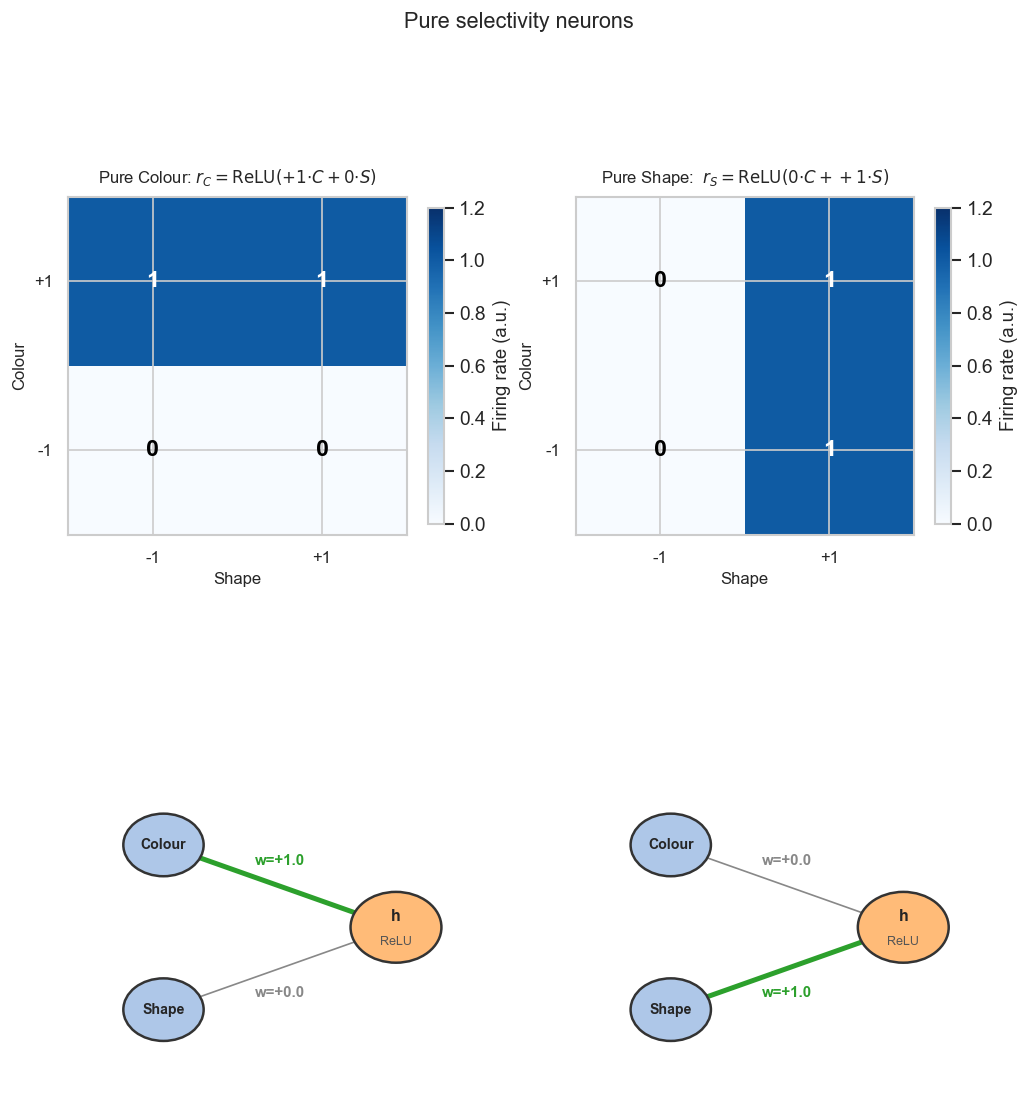

In [6]:
# Define the four XOR trial types
colour  = np.array([-1, -1,  1,  1])  # Colour input values
shape   = np.array([-1,  1, -1,  1])  # Shape input values
reward  = np.array([ 1,  0,  0,  1])  # Reward: 1 when same-sign

colours_plot = ['#d62728' if r == 0 else '#2ca02c' for r in reward]
labels_plot  = ['No reward' if r == 0 else 'Reward' for r in reward]
relu = lambda x: np.maximum(0, x)

colour_vals = [-1, 1]
shape_vals  = [-1, 1]

# Pure neuron response matrices
r_colour = np.array([[relu(1*c + 0*s) for s in shape_vals] for c in colour_vals])
r_shape  = np.array([[relu(0*c + 1*s) for s in shape_vals] for c in colour_vals])

fig, axes = plt.subplots(2, 2, figsize=(10, 10),
                          gridspec_kw={'height_ratios': [1.2, 1], 'hspace': 0.55})

pure_panels = [
    (r_colour, r'Pure Colour: $r_C = \mathrm{ReLU}(+1{\cdot}C + 0{\cdot}S)$', 1, 0),
    (r_shape,  r'Pure Shape:  $r_S = \mathrm{ReLU}(0{\cdot}C + +1{\cdot}S)$',  0, 1),
]

for col, (matrix, title, w1, w2) in enumerate(pure_panels):

    # ── Row 0: response heatmap ───────────────────────────────────────────────
    ax = axes[0, col]
    im = ax.imshow(matrix, cmap='Blues', vmin=0, vmax=1.2,
                   aspect='equal', origin='lower')
    for i, c in enumerate(colour_vals):
        for j, s in enumerate(shape_vals):
            val = matrix[i, j]
            ax.text(j, i, f'{val:.0f}', ha='center', va='center',
                    fontsize=14, fontweight='bold',
                    color='white' if val > 0.6 else 'black')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['-1', '+1'], fontsize=10)
    ax.set_yticklabels(['-1', '+1'], fontsize=10)
    ax.set_xlabel('Shape', fontsize=10)
    ax.set_ylabel('Colour', fontsize=10)
    ax.set_title(title, fontsize=10, pad=8)
    plt.colorbar(im, ax=ax, shrink=0.8, label='Firing rate (a.u.)')

    # ── Row 1: neuron schematic ───────────────────────────────────────────────
    draw_neuron_schematic(axes[1, col], w1=w1, w2=w2)

plt.suptitle('Pure selectivity neurons', fontsize=13, y=1.01)

plt.show()

Notice that each neuron's response is **constant along one axis**: the Colour neuron fires the same regardless of Shape (same value across columns), and vice versa. Neither neuron responds to the **conjunction** of the two inputs.

### The 2D firing rate state space

Now let's ask: if we use the firing rates of these two neurons as coordinates, where do the four XOR trial types sit in this **population state space**? Can a downstream linear readout — a line in this 2D space — separate the rewarded from non-rewarded trials?

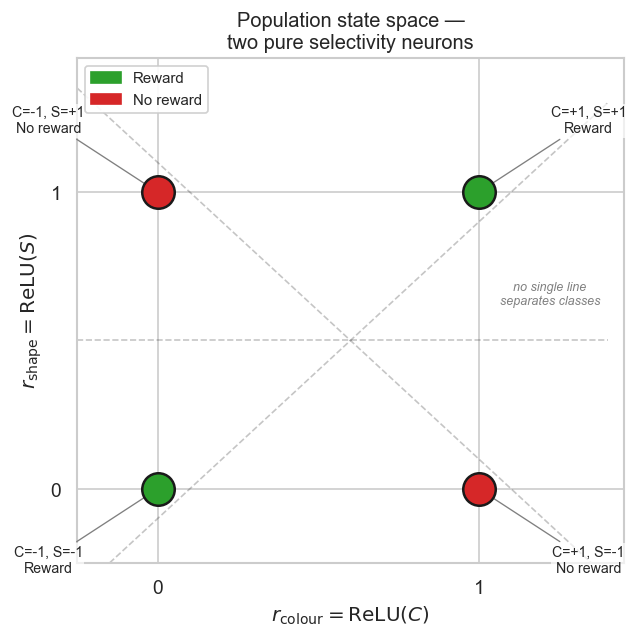

Firing rates per trial:
  C=-1, S=-1 → r_C=0, r_S=0  [Reward]
  C=-1, S=+1 → r_C=0, r_S=1  [No reward]
  C=+1, S=-1 → r_C=1, r_S=0  [No reward]
  C=+1, S=+1 → r_C=1, r_S=1  [Reward]


In [7]:
# Compute firing rates for each trial type
r_c = relu(colour)   # pure colour neuron response per trial
r_s = relu(shape)    # pure shape neuron response per trial

fig, ax = plt.subplots(figsize=(5.5, 5.5))

# ── Failed boundaries (dashed lines only, no shading) ─────────────────────
x_line = np.linspace(-0.25, 1.4, 100)
for slope, intercept in [(-1, 1.1), (1, -0.1), (0, 0.5)]:
    ax.plot(x_line, slope * x_line + intercept, 'k--', lw=1.0, alpha=0.25)
ax.text(1.22, 0.62, 'no single line\nseparates classes', fontsize=7.5,
        color='gray', ha='center', style='italic')

# ── Plot each trial in firing rate space ──────────────────────────────────
offsets = [(-0.22, -0.16), (-0.22, 0.16), (0.22, -0.16), (0.22, 0.16)]
for i in range(4):
    ax.scatter(r_c[i], r_s[i], c=colours_plot[i],
               s=380, zorder=5, edgecolors='k', linewidths=1.5)
    ox, oy = offsets[i]
    ax.annotate(
        f'C={colour[i]:+d}, S={shape[i]:+d}\n{labels_plot[i]}',
        xy=(r_c[i], r_s[i]),
        xytext=(r_c[i] + ox + np.sign(ox)*0.12,
                r_s[i] + oy + np.sign(oy)*0.08),
        ha='center', va='center', fontsize=8.5,
        arrowprops=dict(arrowstyle='-', color='gray', lw=0.8),
        bbox=dict(fc='white', ec='none', alpha=0.7, pad=1))

ax.set_xlim(-0.25, 1.45)
ax.set_ylim(-0.25, 1.45)
ax.set_xlabel(r'$r_{\mathrm{colour}} = \mathrm{ReLU}(C)$', fontsize=12)
ax.set_ylabel(r'$r_{\mathrm{shape}}  = \mathrm{ReLU}(S)$',  fontsize=12)
ax.set_title('Population state space —\ntwo pure selectivity neurons', fontsize=12)
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

reward_patch   = mpatches.Patch(color=C_REWARD,   label='Reward')
noreward_patch = mpatches.Patch(color=C_NOREWARD, label='No reward')
ax.legend(handles=[reward_patch, noreward_patch], loc='upper left', fontsize=9,
          framealpha=0.9)

plt.tight_layout()
plt.show()

print('Firing rates per trial:')
print(f'  C=-1, S=-1 → r_C={relu(-1):.0f}, r_S={relu(-1):.0f}  [Reward]')
print(f'  C=-1, S=+1 → r_C={relu(-1):.0f}, r_S={relu(+1):.0f}  [No reward]')
print(f'  C=+1, S=-1 → r_C={relu(+1):.0f}, r_S={relu(-1):.0f}  [No reward]')
print(f'  C=+1, S=+1 → r_C={relu(+1):.0f}, r_S={relu(+1):.0f}  [Reward]')


The four trial types map to the **corners of a unit square** in firing rate space. The rewarded trials sit on the **diagonal** — $(0,0)$ and $(1,1)$ — while the non-rewarded trials sit on the **off-diagonal** — $(0,1)$ and $(1,0)$.

No straight line can separate the diagonal from the off-diagonal corners. Any line that correctly separates one rewarded point will necessarily misclassify the other. This is the geometric signature of XOR.

---
## 1.4 The solution: a third neuron with mixed selectivity

What if we add a **third neuron** that receives input from both Colour and Shape with equal positive weights?

$$r_{\text{mixed}} = \text{ReLU}(+0.5 \cdot C + +0.5 \cdot S)$$

Unlike the pure selectivity neurons, this neuron responds to the **conjunction** of the two inputs. Adding it as a third dimension to the population state space lifts the four XOR points into 3D — and they become **linearly separable**.

The schematic below shows the circuit, followed by the 3D state space.

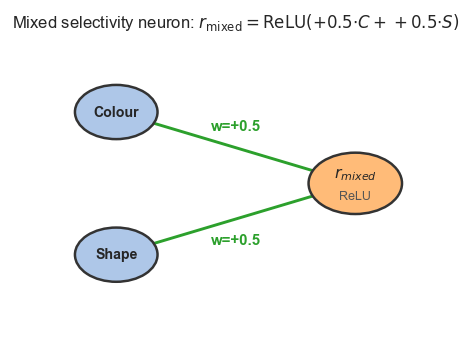

In [8]:
# Draw the mixed selectivity neuron schematic
fig, ax = plt.subplots(figsize=(4, 3))
draw_neuron_schematic(ax, w1=0.5, w2=0.5, label='$r_{mixed}$')
ax.set_title(r'Mixed selectivity neuron: $r_{\mathrm{mixed}} = \mathrm{ReLU}(+0.5{\cdot}C + +0.5{\cdot}S)$',
             fontsize=10, pad=8)
plt.tight_layout()
plt.show()

In [9]:
import plotly.graph_objects as go

r_c        = relu(colour)
r_s        = relu(shape)
mixed_relu = relu(0.5*colour + 0.5*shape)

# ── Corrected separating plane ────────────────────────────────────────────
# w = [-1, -1, 3],  b = 0.5
# Plane surface:  r_mix = (r_C + r_S - 0.5) / 3
g = 25
xx, yy = np.meshgrid(np.linspace(-0.1, 1.2, g),
                      np.linspace(-0.1, 1.2, g))
zz = np.clip((xx + yy - 0.5) / 3.0, -0.15, 1.15)

fig = go.Figure()

# Plane
fig.add_trace(go.Surface(
    x=xx, y=yy, z=zz,
    colorscale=[[0, 'rgba(70,130,180,0.15)'], [1, 'rgba(70,130,180,0.15)']],
    showscale=False, name='Separating plane',
    hoverinfo='skip', opacity=0.35,
))

# Drop-lines + floor shadows
floor_z = -0.15
for i in range(4):
    c = C_REWARD if reward[i] else C_NOREWARD
    # Drop-line
    fig.add_trace(go.Scatter3d(
        x=[r_c[i], r_c[i]], y=[r_s[i], r_s[i]],
        z=[floor_z, mixed_relu[i]],
        mode='lines', line=dict(color='gray', width=2, dash='dot'),
        showlegend=False, hoverinfo='skip',
    ))
    # Floor shadow
    fig.add_trace(go.Scatter3d(
        x=[r_c[i]], y=[r_s[i]], z=[floor_z],
        mode='markers',
        marker=dict(size=5, color=c, opacity=0.3, line=dict(width=0)),
        showlegend=False, hoverinfo='skip',
    ))

# Main points
for cls, label, idxs in [('Reward', C_REWARD, [0,3]),
                          ('No reward', C_NOREWARD, [1,2])]:
    fig.add_trace(go.Scatter3d(
        x=r_c[idxs], y=r_s[idxs], z=mixed_relu[idxs],
        mode='markers+text',
        marker=dict(size=10, color=label, line=dict(width=2, color='black')),
        text=[f'({colour[i]:+d},{shape[i]:+d})' for i in idxs],
        textposition='top center', textfont=dict(size=10),
        name=cls,
    ))

fig.update_layout(
    title=dict(text='3D state space — linearly separable<br>with mixed selectivity',
               font=dict(size=14)),
    scene=dict(
        xaxis_title='r_C = ReLU(C)',
        yaxis_title='r_S = ReLU(S)',
        zaxis_title='r_mixed = ReLU(0.5C+0.5S)',
        xaxis=dict(dtick=1), yaxis=dict(dtick=1), zaxis=dict(dtick=1, range=[floor_z, 1.15]),
        camera=dict(eye=dict(x=1.6, y=-1.6, z=0.9)),
    ),
    width=650, height=550, margin=dict(l=10, r=10, t=50, b=10),
    legend=dict(x=0.02, y=0.98),
)
fig.show()

# ── Verify the corrected linear readout ───────────────────────────────────
R3d = np.stack([r_c, r_s, mixed_relu], axis=1)
w, b = np.array([-1., -1., 3.]), 0.5
print('Linear readout  w = [-1, -1, 3],  b = 0.5')
print(f'{"Trial":<14} {"r_C":>4} {"r_S":>4} {"r_mix":>6} {"w·r+b":>7}  {"Correct?"}')
print('-' * 52)
trial_labels = ['C=-1, S=-1', 'C=-1, S=+1', 'C=+1, S=-1', 'C=+1, S=+1']
expected     = ['Reward', 'No reward', 'No reward', 'Reward']
for i in range(4):
    logit   = R3d[i] @ w + b
    pred    = 'Reward' if logit > 0 else 'No reward'
    correct = '✓' if pred == expected[i] else '✗'
    print(f'{trial_labels[i]:<14} {r_c[i]:>4.0f} {r_s[i]:>4.0f} '
          f'{mixed_relu[i]:>6.0f} {logit:>7.1f}  {correct}')


Linear readout  w = [-1, -1, 3],  b = 0.5
Trial           r_C  r_S  r_mix   w·r+b  Correct?
----------------------------------------------------
C=-1, S=-1        0    0      0     0.5  ✓
C=-1, S=+1        0    1      0    -0.5  ✓
C=+1, S=-1        1    0      0    -0.5  ✓
C=+1, S=+1        1    1      1     1.5  ✓


The separating plane uses all three dimensions. The green/red shading on the plane shows which side corresponds to each class:

| Trial | $r_C$ | $r_S$ | $r_{\text{mixed}}$ | Rewarded | Side of plane |
|-------|:-----:|:-----:|:------------------:|:--------:|:-------------:|
| (−1, −1) | 0 | 0 | 0 | ✓ | above |
| (−1, +1) | 0 | 1 | 0 | ✗ | below |
| (+1, −1) | 1 | 0 | 0 | ✗ | below |
| (+1, +1) | 1 | 1 | 1 | ✓ | above |

The mixed neuron lifts $(+1,+1)$ to $r_{\text{mixed}}=1$ while keeping the other three at zero — just enough for a tilted plane to slip between the two classes. A downstream neuron with weights $\mathbf{w}=[-1,\,-1,\,3]$ and bias $b=0.5$ reads this out perfectly, as verified above.

> 💡 **Key insight**: The ReLU nonlinearity is essential here. Without it, the mixed neuron's output would be $0.5C + 0.5S$, which is just another linear combination — adding a third dimension that is linearly dependent on the first two, and therefore useless for separation. The ReLU *breaks this linearity*: it clips the output to zero whenever $C + S < 0$, which means the neuron only fires when **both** inputs are positive (the $(+1,+1)$ trial). This selective silence is what creates the asymmetry needed to separate the XOR classes in 3D.


---
# Section 2 — from toy XOR to a temporal decision task

In Section 1 we saw that solving XOR requires **mixed selectivity** — neurons that respond to conjunctions of inputs, not just individual features. But the example was deliberately simple: two static inputs and an instant decision.

Real neural circuits face a harder version of the same problem:

1. **Stimuli arrive at different times** — the network must hold information in memory.
2. **There are irrelevant (distractor) dimensions** — the network must learn what to ignore.
3. **The decision is reported in a later time window** — the network must gate its output.

In this section we set up exactly such a task and visualise its structure before looking inside any network.

---
## 2.1 Task overview

We use a task framework (`DataGenerator`) that generates trials with three binary sensory features — **Colour**, **Shape**, and **Width** — each taking values $-1$ or $+1$. This gives $2^3 = 8$ unique trial conditions.

The **reward rule** is the same Colour $\oplus$ Shape (XNOR) computation from Section 1. Width is present but **completely irrelevant** — the network must learn to ignore it.

| Condition | Colour | Shape | Width | Rewarded? | Why |
|:---------:|:------:|:-----:|:-----:|:---------:|:----|
| 0 | −1 | −1 | −1 | ✓ | Colour == Shape |
| 1 | −1 | −1 | +1 | ✓ | Colour == Shape |
| 2 | −1 | +1 | −1 | ✗ | Colour ≠ Shape |
| 3 | −1 | +1 | +1 | ✗ | Colour ≠ Shape |
| 4 | +1 | −1 | −1 | ✗ | Colour ≠ Shape |
| 5 | +1 | −1 | +1 | ✗ | Colour ≠ Shape |
| 6 | +1 | +1 | −1 | ✓ | Colour == Shape |
| 7 | +1 | +1 | +1 | ✓ | Colour == Shape |

Notice that conditions 0 & 1 are identical except for Width, and both are rewarded — the same holds for conditions 6 & 7. The network cannot solve the task by attending to Width; it must build a conjunctive representation of Colour and Shape, just as in Section 1.


In [11]:
# ── Task configuration ──────────────────────────────────────────────────────
# We define the config inline so the tutorial is self-contained.

task_config = {
    'temporal': {
        't_min': -500,        # trial start (ms)
        't_max': 1500,        # trial end   (ms)
        'dt': 20,             # time step   (ms)
        'colour_onset': 0.0,  # Colour stimulus appears
        'colour_offset': 1000.0,
        'shape_onset': 500.0, # Shape stimulus appears (500 ms after Colour)
        'shape_offset': 1000.0,
        'reward_onset': 1000.0,   # decision window
        'reward_offset': 1200.0,
    },
    'data': {
        'n_trials': 1024,
        'input_noise_std': 0.15,
        'batch_size': 32,
        'num_workers': 0,
        'encoding_mode': 'orthogonal',     # inputs ∈ {-1, +1}
        'experiment_type': 'abstract_binary',
        'task_indices': [14],               # 14 = Colour XNOR Shape
    },
    'hardware': {
        'device': 'cpu',
    },
}

data_generator = DataGenerator(config=task_config, seed=42)

print(f'Experiment type : {data_generator.experiment_type.name}')
print(f'Task rule       : {data_generator.abstract_task_type}')
print(f'Task index      : {data_generator.classification_index}')
print(f'Encoding        : {data_generator.encoding_mode.value}')
print(f'Trial window    : {data_generator.temporal_params.t_min} – {data_generator.temporal_params.t_max} ms')
print(f'Time step (dt)  : {data_generator.temporal_params.dt} ms')


Experiment type : abstract_binary
Task rule       : Color XOR Shape
Task index      : 14
Encoding        : orthogonal
Trial window    : -500 – 1500 ms
Time step (dt)  : 20 ms


---
## 2.2 Design matrix

The **design matrix** defines what each trial condition looks like — the feature values and the associated reward. Each row is one of the 8 conditions; each column is a feature channel (Colour, Shape, Width) or the reward signal.

With **orthogonal encoding**, features take values $\{-1, +1\}$ rather than $\{0, 1\}$. This is a common choice in computational neuroscience because it centres the inputs around zero and makes the representation symmetric.

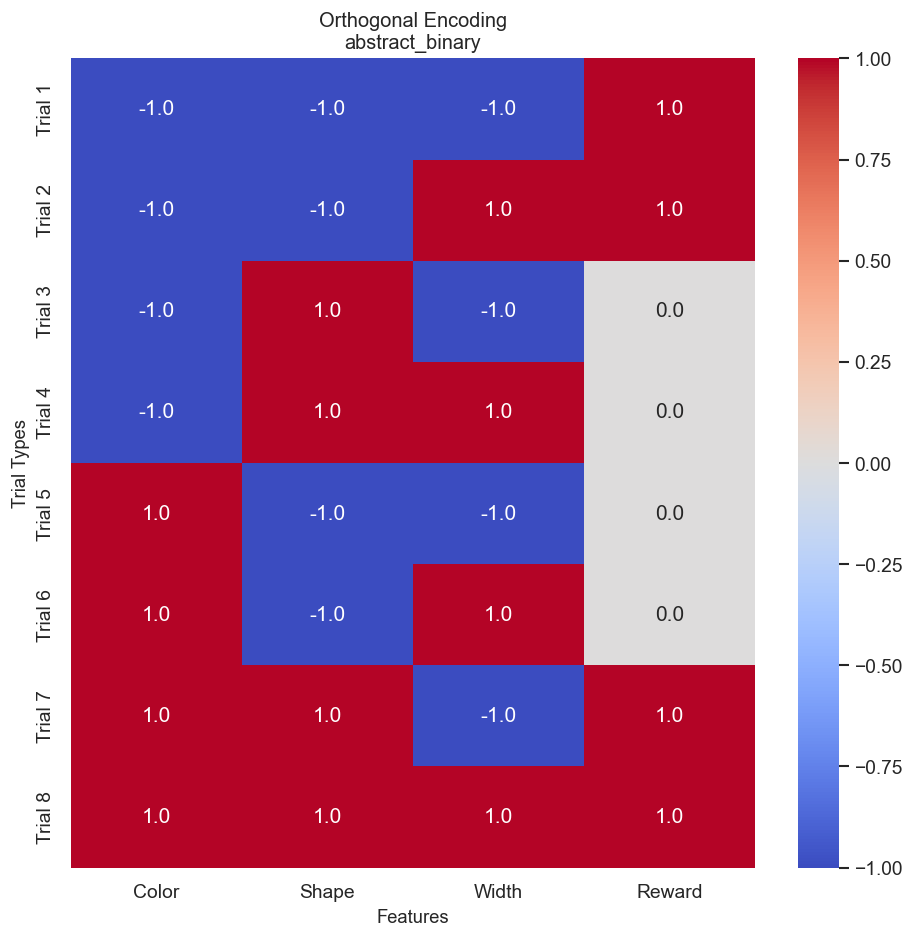

In [12]:
data_generator.plot_design_matrices()

---
## 2.3 Temporal structure

Unlike the static XOR in Section 1, stimuli here are delivered **sequentially** within each trial:

| Event | Onset | Offset | Description |
|:------|------:|-------:|:------------|
| Colour | 0 ms | 1000 ms | First stimulus — presented for the full stimulus period |
| Shape | 500 ms | 1000 ms | Second stimulus — arrives 500 ms after Colour |
| Width | 500 ms | 1000 ms | Distractor — arrives together with Shape |
| Reward window | 1000 ms | 1200 ms | The network must report its decision here |

This temporal offset is crucial: **the network must hold Colour in memory** for 500 ms before Shape arrives. Only then can it compute the conjunction. The event sequence below shows these temporal signals.

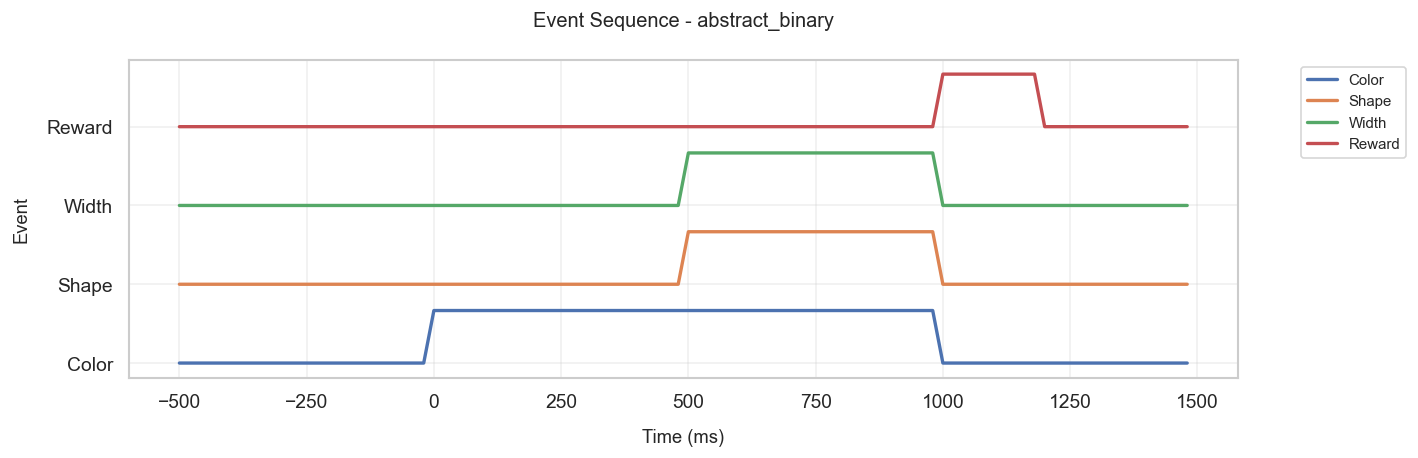

In [13]:
data_generator.plot_event_sequence()

---
## 2.4 What the network sees and must produce

Each of the 8 trial types produces a different input trajectory (coloured lines) and a different target output (grey shading = reward). Gaussian noise is added to the inputs to prevent the network from memorising exact patterns.

The network receives **3 input channels** at each time step and must produce **2 output channels** (reward vs. no-reward) during the reward window. Outside the reward window, the target is zero — the network is free to do whatever it likes internally.

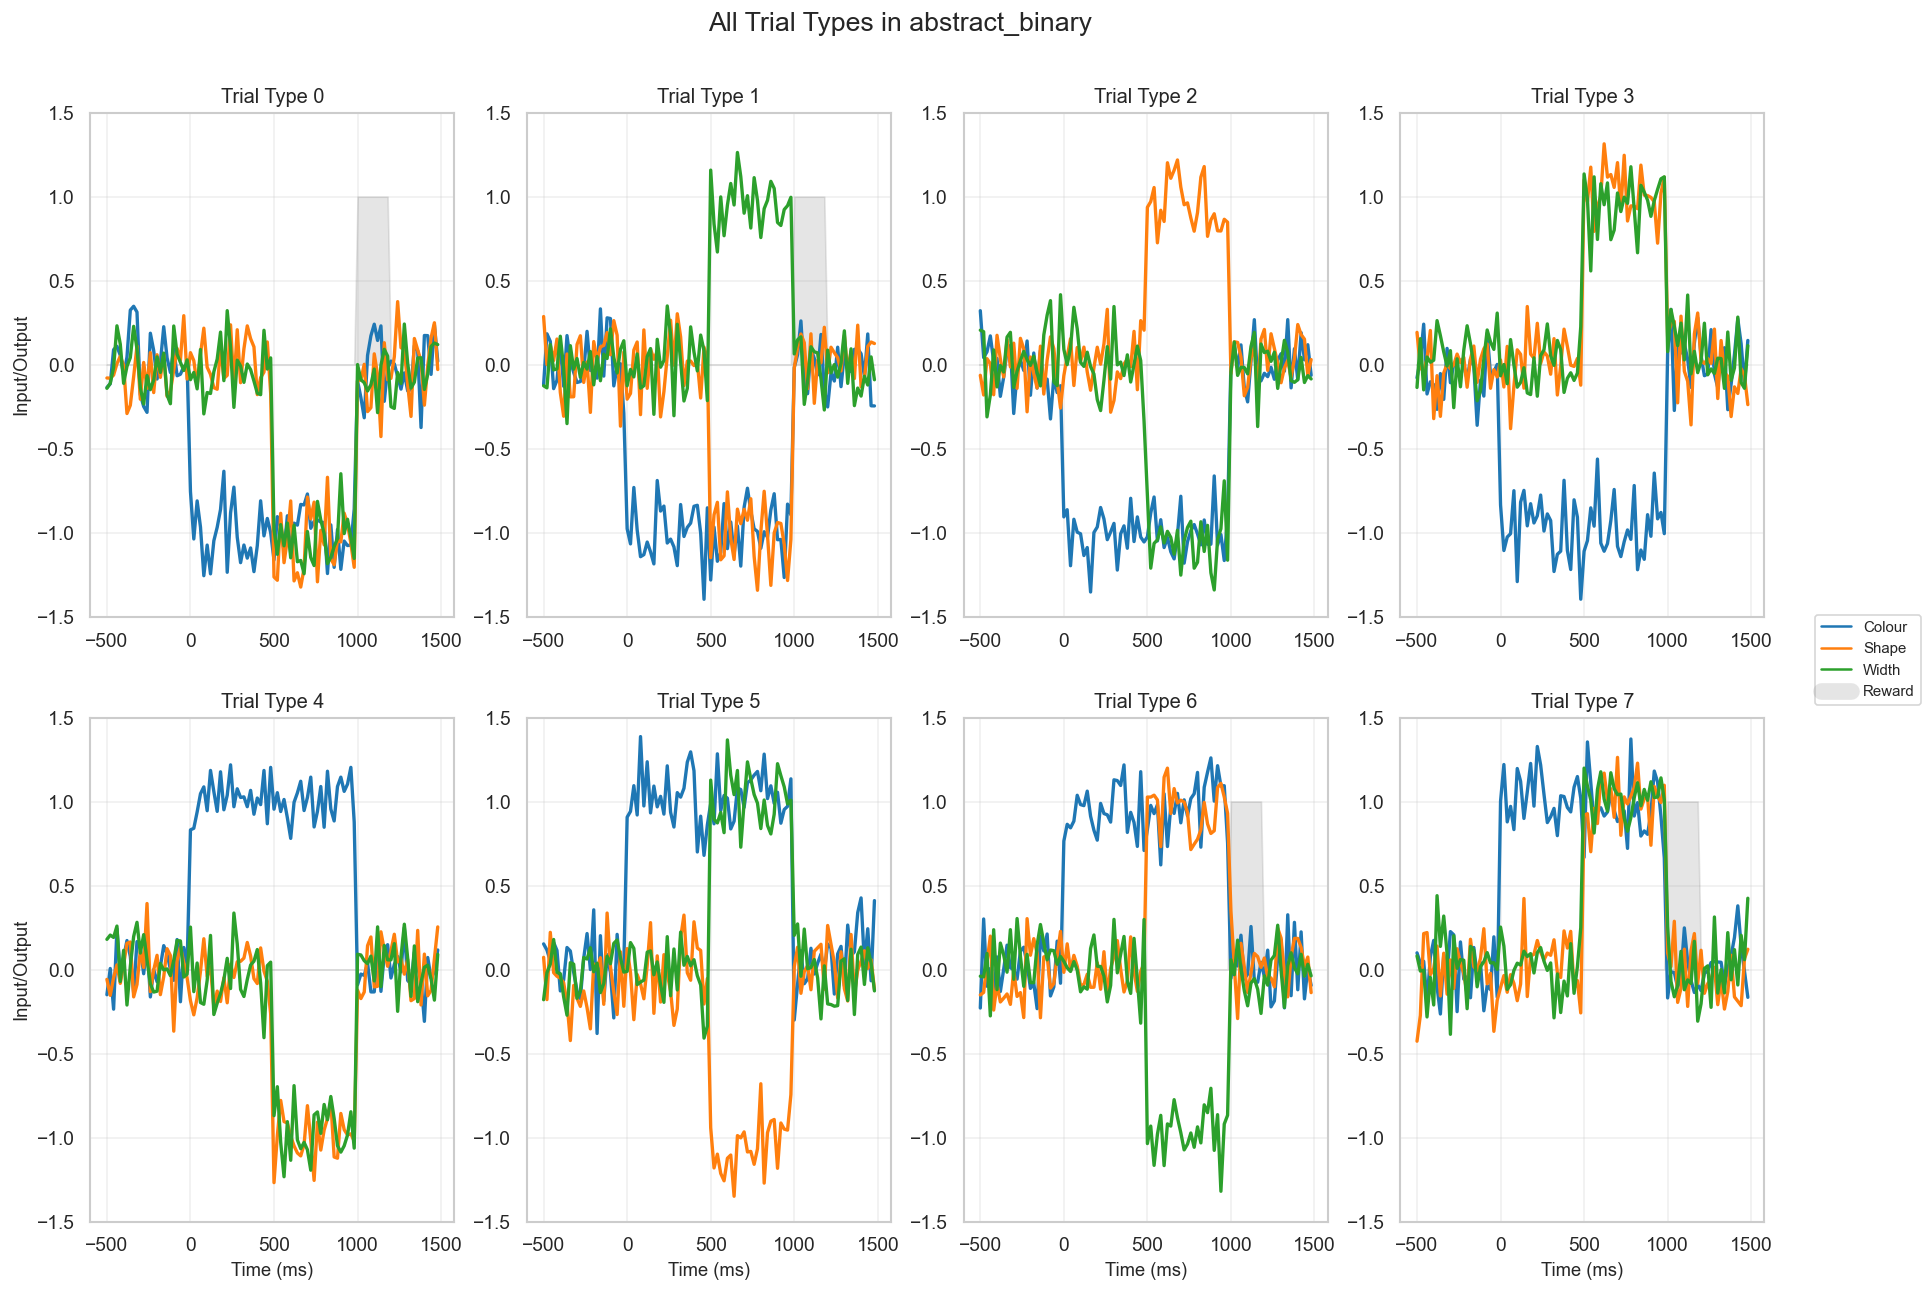


abstract_binary Data:
Input shape: torch.Size([480, 100, 3])
Output shape: torch.Size([480, 100, 2])
Number of unique trial types: 8

Summary of trial characteristics:

Trial Type 0:
Active inputs: Colour, Shape, Width
Reward: Yes

Trial Type 1:
Active inputs: Colour, Shape, Width
Reward: Yes

Trial Type 2:
Active inputs: Colour, Shape, Width
Reward: No

Trial Type 3:
Active inputs: Colour, Shape, Width
Reward: No

Trial Type 4:
Active inputs: Colour, Shape, Width
Reward: No

Trial Type 5:
Active inputs: Colour, Shape, Width
Reward: No

Trial Type 6:
Active inputs: Colour, Shape, Width
Reward: Yes

Trial Type 7:
Active inputs: Colour, Shape, Width
Reward: Yes


In [14]:
data_generator.plot_trial_types()

---
# Section 3 — Building a Continuous-Time RNN

We now build the recurrent neural network that will learn the XOR task from Section 2. The architecture is a **continuous-time RNN (CTRNN)** — a standard model in computational neuroscience that approximates the dynamics of a population of neurons with a single differential equation.

The key idea: instead of updating the hidden state instantaneously (as in a vanilla RNN), the CTRNN uses a **time constant** $\tau$ that controls how quickly the hidden state responds to new input. This produces smooth, biologically plausible dynamics.

---
## 3.1 From continuous to discrete time

The continuous-time dynamics of the hidden state $\mathbf{h}(t)$ are:

$$\tau \frac{d\mathbf{h}(t)}{dt} = -\mathbf{h}(t) + \varphi\!\big(W_{\text{in}}\, \mathbf{x}(t) + W_{\text{hh}}\, \mathbf{h}(t)\big)$$

where $\varphi$ is a pointwise nonlinearity (ReLU).

Discretising with time step $dt$ using the **Euler method** gives the update rule the network will actually execute at each step:

$$\boxed{\mathbf{h}_t = (1 - \alpha)\, \mathbf{h}_{t-1} \;+\; \alpha\, \varphi\!\big(W_{\text{in}}\, \mathbf{x}_t + W_{\text{hh}}\, \mathbf{h}_{t-1}\big)}$$

where $\alpha = dt / \tau$ is the **leak rate**.

The output is a linear readout of the hidden state:

$$\mathbf{y}_t = W_{\text{out}}\, \mathbf{h}_t$$

### Intuition for $\alpha$

- When $\alpha = 1$ (i.e. $dt = \tau$), the old state is completely replaced — this recovers a standard discrete-time RNN.
- When $\alpha \ll 1$, the state changes slowly — the network has **inertia** and integrates inputs over time. This is the biologically realistic regime.
- In our task, $dt = 20\text{ ms}$ and $\tau = 50\text{ ms}$, so $\alpha = 0.4$. The hidden state is a weighted average of 40% new drive and 60% previous state.

> 💡 **Why continuous time?** Real neurons don't update in discrete steps. The time constant $\tau$ captures the effective membrane time constant of a neural population, and the smooth dynamics it produces are closer to what we observe in cortical recordings.

---
## 3.2 Network architecture

```
                               ┌────────────┐
          x_t ──► [ W_in ] ──► │  hidden    │──► [ W_out ] ──► y_t
                   ┌─────────► │  state h_t │
                   │           └──────┬─────┘
                   │                  │
                   └── [ W_hh ] ◄─────┘
```

Three learnable weight matrices:

| Matrix | Shape | Role |
|:-------|:------|:-----|
| $W_{\text{in}}$ | (hidden, input) | Maps input features to hidden state |
| $W_{\text{hh}}$ | (hidden, hidden) | Recurrent connections within the hidden layer |
| $W_{\text{out}}$ | (output, hidden) | Reads out the decision from hidden activity |

Each matrix has a **plasticity flag** — a boolean that controls whether its weights are updated during training. This lets us freeze specific connections and study which parts of the circuit are necessary for learning.

---
## 3.3 Exercise — implement the recurrence

The cell below contains the full `CTRNN` class. Everything is implemented **except** the `recurrence` method — the single time-step update that is the heart of the network.

Your task: replace the `raise NotImplementedError` with the discretised equation from Section 3.1. You have access to:

| What you need | How to get it |
|:---|:---|
| $\alpha$ | `self.alpha` |
| $\varphi(\cdot)$ (ReLU) | `self.nonlinearity(...)` |
| $W_{\text{in}} \cdot x_t$ | `self.input2h(x_t)` |
| $W_{\text{hh}} \cdot h_{t-1}$ | `self.h2h(h_prev)` |

In [15]:
import torch
import torch.nn as nn
import numpy as np
from typing import Optional, Tuple


class CTRNN(nn.Module):
    """Continuous-time recurrent neural network."""

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        output_size: int,
        dt: float = 20.0,
        tau: float = 50.0,
        input_plastic: bool = True,
        hidden_plastic: bool = True,
        output_plastic: bool = True,
        seed: int = None,
    ):
        super().__init__()

        # ── Reproducibility ───────────────────────────────────────────
        if seed is not None:
            torch.manual_seed(seed)
            np.random.seed(seed)

        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.alpha = dt / tau          # leak rate
        self.nonlinearity = nn.ReLU()  # φ

        # ── Learnable layers ────────────────────────────────────────
        self.input2h = nn.Linear(input_size, hidden_size)   # W_in
        self.h2h     = nn.Linear(hidden_size, hidden_size)  # W_hh
        self.h2o     = nn.Linear(hidden_size, output_size)  # W_out

        # ── Plasticity flags ────────────────────────────────────────
        # requires_grad_(False) freezes a layer's weights during training
        self.input2h.requires_grad_(input_plastic)
        self.h2h.requires_grad_(hidden_plastic)
        self.h2o.requires_grad_(output_plastic)

        self._initialize_weights()

    # ── Weight initialisation ───────────────────────────────────────
    def _initialize_weights(self):
        for layer in [self.input2h, self.h2h, self.h2o]:
            nn.init.kaiming_normal_(layer.weight)
            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

    # ── Hidden-state helper ─────────────────────────────────────────
    def init_hidden(self, batch_size: int, device: torch.device) -> torch.Tensor:
        return torch.zeros(batch_size, self.hidden_size, device=device)

    def recurrence(self, x_t, h_prev):
        h_new = self.nonlinearity(
            self.input2h(x_t) + self.h2h(h_prev)
        )
        h_t = (1 - self.alpha) * h_prev + self.alpha * h_new
        return h_t

    # ── Forward pass (loops over time) ──────────────────────────────
    def forward(
        self, x: torch.Tensor, hidden: Optional[torch.Tensor] = None
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Run the RNN over a full input sequence.

        Args:
            x      : (time_steps, batch, input_size)
            hidden : optional initial state (batch, hidden_size)

        Returns:
            output     : (time_steps, batch, output_size)
            hidden_all : (time_steps, batch, hidden_size)
        """
        if hidden is None:
            hidden = self.init_hidden(x.shape[1], x.device)

        hidden_all = []
        for t in range(x.size(0)):
            hidden = self.recurrence(x[t], hidden)
            hidden_all.append(hidden)

        hidden_all = torch.stack(hidden_all, dim=0)
        output     = self.h2o(hidden_all)
        return output, hidden_all

    # ── Convenience: extract activations & accuracy ─────────────────
    def get_activations(
        self, X: torch.Tensor, y: torch.Tensor, mask: torch.Tensor,
    ) -> Tuple[np.ndarray, float]:
        self.eval()
        with torch.no_grad():
            outputs, hidden_states = self(X.transpose(0, 1))
            outputs_flat  = outputs[mask].reshape(-1, outputs.shape[-1])
            targets_flat  = y.transpose(0, 1)[mask].reshape(-1, y.shape[-1])
            accuracy = (outputs_flat.argmax(1) == targets_flat.argmax(1)).float().mean().item()
            activations = hidden_states.transpose(0, 1).cpu().numpy()
        return activations, accuracy


---
<details>
<summary><b>Click to reveal solution</b></summary>

```python
def recurrence(self, x_t, h_prev):
    h_new = self.nonlinearity(
        self.input2h(x_t) + self.h2h(h_prev)
    )
    h_t = (1 - self.alpha) * h_prev + self.alpha * h_new
    return h_t
```

</details>

---
## 3.4 Verify the model

Once you have implemented `recurrence`, the cell below creates a model and runs a single forward pass on dummy data to check that everything works. It also prints the architecture summary and plasticity settings.

In [16]:
# ── Create model with the same dimensions as our task ────────────────
model = CTRNN(
    input_size=3,       # Colour, Shape, Width
    hidden_size=30,     # 30 recurrent units
    output_size=2,      # Reward vs No-reward
    dt=20.0,            # time step  (ms)
    tau=50.0,           # time constant (ms)
    input_plastic=True,
    hidden_plastic=True,
    output_plastic=True,
    seed=42,
)

print(model)
print(f'\nLeak rate α = dt/τ = {model.alpha:.2f}')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

print('\nPlasticity:')
for name, param in model.named_parameters():
    print(f'  {name:<16s}  shape={str(list(param.shape)):<14s}  trainable={param.requires_grad}')

# ── Smoke test: forward pass on random data ─────────────────────────
T, B = 100, 8   # 100 time steps, batch of 8
x_dummy = torch.randn(T, B, 3)
output, hidden = model(x_dummy)
print(f'\nForward pass OK!')
print(f'  Input shape  : {list(x_dummy.shape)}  (time, batch, input)')
print(f'  Hidden shape : {list(hidden.shape)}   (time, batch, hidden)')
print(f'  Output shape : {list(output.shape)}   (time, batch, output)')


CTRNN(
  (nonlinearity): ReLU()
  (input2h): Linear(in_features=3, out_features=30, bias=True)
  (h2h): Linear(in_features=30, out_features=30, bias=True)
  (h2o): Linear(in_features=30, out_features=2, bias=True)
)

Leak rate α = dt/τ = 0.40
Total parameters: 1,112
Trainable params: 1,112

Plasticity:
  input2h.weight    shape=[30, 3]         trainable=True
  input2h.bias      shape=[30]            trainable=True
  h2h.weight        shape=[30, 30]        trainable=True
  h2h.bias          shape=[30]            trainable=True
  h2o.weight        shape=[2, 30]         trainable=True
  h2o.bias          shape=[2]             trainable=True

Forward pass OK!
  Input shape  : [100, 8, 3]  (time, batch, input)
  Hidden shape : [100, 8, 30]   (time, batch, hidden)
  Output shape : [100, 8, 2]   (time, batch, output)


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# ★ EXERCISE: What happens to the dynamics as τ changes?
# ══════════════════════════════════════════════════════════════════════
# Compute α for three different time constants and think about what
# each regime means for the network's memory.
#
# τ = 20 ms (fast)   → α = ?
# τ = 50 ms (default)→ α = ?
# τ = 200 ms (slow)  → α = ?
#
# Which regime would be best for a task that requires holding
# information over a long delay?

dt = 20.0  # fixed time step

# ── YOUR CODE HERE ──────────────────────────────────────────────────
raise NotImplementedError("Compute alpha for each tau")
# ──────────────────────────────────────────────────────────────────


---
# Section 4 — Probing the Untrained Network

Before we train anything, let's ask: **what does the network already know?**

A randomly initialised CTRNN with ReLU nonlinearities will produce activity patterns when driven by input. These patterns live in a 30-dimensional hidden state space. We will:

1. Pass the 8 trial conditions through the untrained network and collect its hidden-state trajectories.
2. **Decode** all task variables from the hidden states at each time-step.

This gives us a baseline: anything the trained network does better must be a consequence of learning.

---
## 4.1 Collect hidden-state trajectories

We generate a batch of trials (with noise) and pass them through the untrained model. The `get_activations` method returns the hidden state at every time-step for every trial.

In [17]:
# ── Generate data ────────────────────────────────────────────────────
X, y, trial_types, times = data_generator.generate_data(
    n_trials=1024,
    input_noise_std=0.15,
    return_trial_types=True,
    return_times=True,
)
mask = data_generator.generate_mask(mask_format='bool')

# ── Collect activations from the untrained model ─────────────────────
activations, accuracy = model.get_activations(X, y, mask)

print(f'Activations shape : {activations.shape}  (trials, timesteps, neurons)')
print(f'Trial types       : {np.unique(trial_types)}  ({len(trial_types)} trials total)')
print(f'Untrained accuracy: {accuracy:.1%}  (chance = 50%)')


Activations shape : (1024, 100, 30)  (trials, timesteps, neurons)
Trial types       : [0 1 2 3 4 5 6 7]  (1024 trials total)
Untrained accuracy: 64.3%  (chance = 50%)


---
## 4.2 Decoding task variables across time

To test whether each variable is linearly separable in the full 30-dimensional hidden space, we use a **linear Support Vector Machine (SVM)** — a classifier that finds the hyperplane maximising the margin between two classes. At each time-step, we take the hidden state vector of every trial, label trials according to the variable we want to decode (e.g. Colour = $-1$ vs $+1$), and measure how accurately the SVM can classify them using **split-half cross-validation**: half the trials are used to train the classifier, the other half to test it, and the roles are swapped. The reported accuracy is the average of both splits.

We decode four variables:

| Variable | What it tests |
|:---------|:--------------|
| **Colour** | Can we read out which colour was shown? |
| **Shape** | Can we read out which shape was shown? |
| **Width** | Can we read out the distractor? |
| **XOR** (Colour XNOR Shape) | Can we read out the task-relevant decision variable? |

If the untrained network already has high decoding for Colour and Shape (linearly present in the input) but low decoding for XOR (which requires nonlinear mixing), that confirms the Section 1 intuition — pure selectivity is not enough.


In [18]:
# ── Get the target vectors for the 4 key variables ──────────────────
decoding_targets, var_ids, _, _ = get_shattering_ids()
var_ids = var_ids.astype(int)
var_names = ['Colour', 'Shape', 'Width', 'XOR (reward)']

# ── Decode each variable at each time-step ──────────────────────────
n_timepoints = activations.shape[1]
scores = {name: [] for name in var_names}

for t in range(n_timepoints):
    X_t = activations[:, t, :]  # (trials, neurons)
    for name, vid in zip(var_names, var_ids):
        y_dec = assign_lables(trial_types, decoding_targets[vid, :])
        scores[name].append(decode(X_t, y_dec))

for name in var_names:
    scores[name] = np.array(scores[name])

print('Decoding done.')
for name in var_names:
    print(f'  {name:<16s}: peak = {scores[name].max():.2f}')


Decoding done.
  Colour          : peak = 1.00
  Shape           : peak = 1.00
  Width           : peak = 1.00
  XOR (reward)    : peak = 1.00


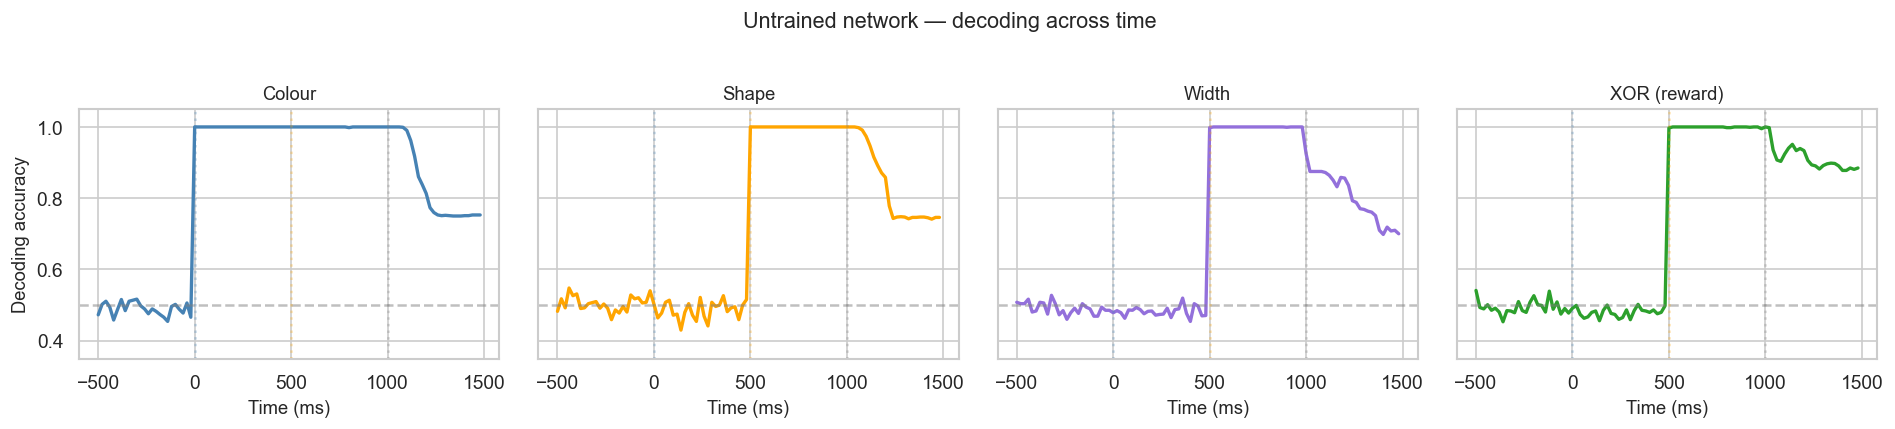

In [19]:
# ── Plot each variable in its own subplot ────────────────────────────
colours_var = ['steelblue', 'orange', 'mediumpurple', C_REWARD]

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, name, col in zip(axes, var_names, colours_var):
    ax.plot(times, scores[name], color=col, lw=2)
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='steelblue', ls=':', alpha=0.3)
    ax.axvline(500, color='orange', ls=':', alpha=0.3)
    ax.axvline(1000, color='gray', ls=':', alpha=0.3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Time (ms)')
    ax.set_ylim(0.35, 1.05)

axes[0].set_ylabel('Decoding accuracy')

plt.suptitle('Untrained network — decoding across time', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## 4.4 What do we learn?

Examine the decoding plots. You should see that:

- **Colour** becomes decodable shortly after its onset (0 ms), and **Shape** and **Width** after theirs (500 ms) — these are linearly present in the input, so even random input weights project them into the hidden state.
- **XOR** (the reward variable) is already decodable!

> 💡 **Key question**: We expected that we need training to decode the XOR. **How** does the network already represent the task variable?

---
# Section 5 — Why does the untrained network already represent XOR?

In Section 4 we saw that XOR is decodable even before training. Where does this come from?

The natural first guess is to look at the **input connectivity**: if a unit receives same-sign weights from Colour and Shape, it should respond more when both inputs agree — exactly the conjunction needed for XOR. Let's test this structural definition, and see whether it's the whole story.

---
## 5.1 Attempt 1 — defining XOR selectivity from input weights

The input weight matrix $W_{\text{in}}$ has shape `(hidden_size, input_size)` = `(30, 3)`. For each hidden unit $j$, the first two columns give the weights from Colour and Shape:

$$w_j^{\text{colour}} = W_{\text{in}}[j, 0], \qquad w_j^{\text{shape}} = W_{\text{in}}[j, 1]$$

A simple structural criterion: a unit is **"XOR-selective by connectivity"** if its Colour and Shape weights have the **same sign** — both positive or both negative. Such a unit's pre-nonlinearity drive $w_C \cdot C + w_S \cdot S$ is largest when Colour and Shape agree, which is exactly the XOR condition.

Let's identify these units, mask them, and see if XOR decoding drops.

Units with same-sign Colour & Shape weights: 15 / 30
Unit indices: [ 0  1  5  6  7 12 17 18 19 21 22 25 27 28 29]


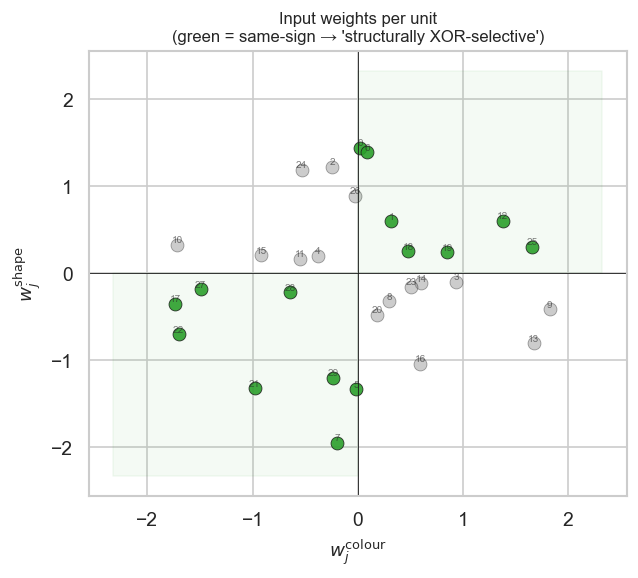

In [20]:
# ── Extract input weights ────────────────────────────────────────────
W_in = model.input2h.weight.detach().cpu().numpy()  # (hidden, input)
w_colour = W_in[:, 0]    # weight from Colour for each unit
w_shape  = W_in[:, 1]    # weight from Shape for each unit

# ── Structural criterion: same sign on Colour and Shape weights ─────
same_sign = (w_colour * w_shape) > 0  # True if both pos or both neg
structural_xor_units = np.where(same_sign)[0]

print(f'Units with same-sign Colour & Shape weights: '
      f'{len(structural_xor_units)} / {W_in.shape[0]}')
print(f'Unit indices: {structural_xor_units}')

# ── Visualise the input weights ─────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5))
for j in range(len(w_colour)):
    c = C_REWARD if same_sign[j] else 'gray'
    alpha = 0.9 if same_sign[j] else 0.4
    ax.scatter(w_colour[j], w_shape[j], c=c, s=60, alpha=alpha,
               edgecolors='k', linewidths=0.5)
    ax.annotate(str(j), (w_colour[j], w_shape[j]), fontsize=6,
                ha='center', va='bottom', alpha=0.6)

ax.axhline(0, color='k', lw=0.5)
ax.axvline(0, color='k', lw=0.5)
# Shade same-sign quadrants
lim = max(abs(ax.get_xlim()[0]), abs(ax.get_xlim()[1]),
          abs(ax.get_ylim()[0]), abs(ax.get_ylim()[1])) * 1.1
ax.fill_between([0, lim], 0, lim, alpha=0.05, color=C_REWARD)
ax.fill_between([-lim, 0], -lim, 0, alpha=0.05, color=C_REWARD)
ax.set_xlabel(r'$w^{\mathrm{colour}}_j$', fontsize=11)
ax.set_ylabel(r'$w^{\mathrm{shape}}_j$', fontsize=11)
ax.set_title('Input weights per unit\n(green = same-sign → \'structurally XOR-selective\')', fontsize=10)
plt.tight_layout()
plt.show()


With random weights, roughly half the units (around 15 out of 30) land in the same-sign quadrants — this is expected, since the probability of two independent random weights sharing a sign is 50%. So by this structural criterion, about half the network is already "XOR-selective" before any training. But does removing them actually destroy the XOR representation? Let's find out.


In [21]:
import copy

def mask_units(model, units_to_mask, X, y, mask):
    """
    Create a copy of the model with specified units fully silenced:
    zero out their rows in W_in, and both rows & columns in W_hh.
    Then re-run the forward pass and return activations.
    """
    masked_model = copy.deepcopy(model)

    with torch.no_grad():
        # Zero input weights TO these units
        masked_model.input2h.weight[units_to_mask, :] = 0.0
        if masked_model.input2h.bias is not None:
            masked_model.input2h.bias[units_to_mask] = 0.0

        # Zero recurrent weights TO and FROM these units
        masked_model.h2h.weight[units_to_mask, :] = 0.0  # rows: input to unit
        masked_model.h2h.weight[:, units_to_mask] = 0.0  # cols: output from unit
        if masked_model.h2h.bias is not None:
            masked_model.h2h.bias[units_to_mask] = 0.0

    activations_masked, acc_masked = masked_model.get_activations(X, y, mask)
    return activations_masked, acc_masked

# ── Mask the structurally XOR-selective units ────────────────────────
print(f'Masking {len(structural_xor_units)} structurally XOR-selective units...')
print(f'  Zeroing their rows in W_in and rows+cols in W_hh, then re-running forward pass.')

activations_struct_masked, acc_struct = mask_units(model, structural_xor_units, X, y, mask)
print(f'  Accuracy after masking: {acc_struct:.1%}')

# ── Re-decode ──────────────────────────────────────────────────────
scores_struct_masked = {name: [] for name in var_names}

for t in range(n_timepoints):
    X_t = activations_struct_masked[:, t, :]
    for name, vid in zip(var_names, var_ids):
        y_dec = assign_lables(trial_types, decoding_targets[vid, :])
        scores_struct_masked[name].append(decode(X_t, y_dec))

for name in var_names:
    scores_struct_masked[name] = np.array(scores_struct_masked[name])


Masking 15 structurally XOR-selective units...
  Zeroing their rows in W_in and rows+cols in W_hh, then re-running forward pass.
  Accuracy after masking: 49.0%


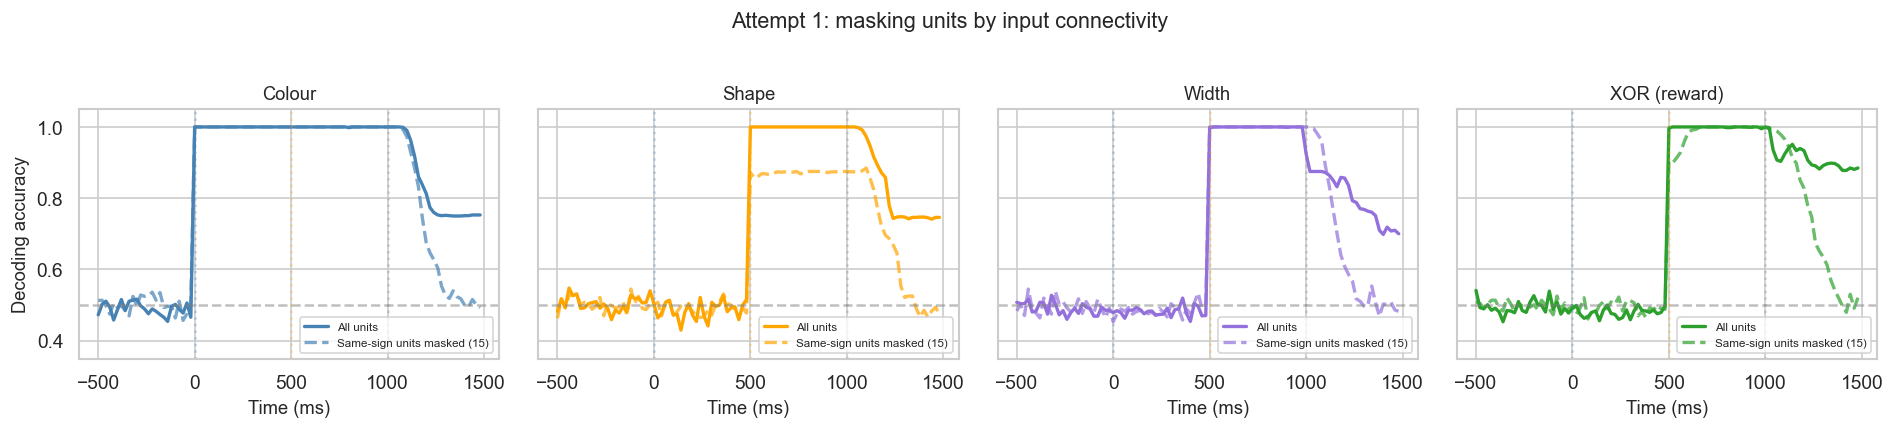

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, name, col in zip(axes, var_names, colours_var):
    ax.plot(times, scores[name], color=col, lw=2, label='All units')
    ax.plot(times, scores_struct_masked[name], color=col, lw=2, ls='--',
            alpha=0.7, label=f'Same-sign units masked ({len(structural_xor_units)})')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='steelblue', ls=':', alpha=0.3)
    ax.axvline(500, color='orange', ls=':', alpha=0.3)
    ax.axvline(1000, color='gray', ls=':', alpha=0.3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Time (ms)')
    ax.set_ylim(0.35, 1.05)
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_ylabel('Decoding accuracy')
plt.suptitle('Attempt 1: masking units by input connectivity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
### ★ Exercise: why does XOR survive structural masking?

We removed all units whose input weights favour the XOR conjunction, yet XOR decoding survived. Before reading the explanation below, try to come up with at least one mechanism by which a unit with *opposite-sign* Colour and Shape input weights (i.e. one that was **not** masked) could still carry XOR information.

*Hint: think about what happens after the first time-step. Where else can a unit get its input from besides $W_{\text{in}}$?*


---
## 5.2 Why the structural definition fails

You should see that XOR decoding **does not collapse** — it may drop slightly, but remains well above chance. Why?

Because input connectivity is not the only source of mixed selectivity. The recurrent connections $W_{\text{hh}}$ mix signals between units at every time-step. A unit with a pure Colour input weight can become XOR-selective if it receives recurrent input from a Shape-selective unit — the conjunction is computed *through the dynamics*, not at the input.

This tells us that a **structural** definition based on connectivity misses the full picture. We need a **functional** definition — one based on what each unit actually *does* in response to the stimuli.

> 💡 **Lesson**: In a recurrent network, selectivity is not just determined by feedforward connectivity — recurrent dynamics can create mixed selectivity that is invisible in the input weights.

---
## 5.3 Attempt 2 — defining XOR selectivity from responses

Instead of looking at weights, we look at what the units actually do. We define an **XOR selectivity index** based on each unit's response to the 8 conditions:

$$\text{XOR\_SI}_j = \overline{r}_j^{\,\text{same}} - \overline{r}_j^{\,\text{diff}}$$

where $\overline{r}_j^{\,\text{same}}$ is the mean activity of unit $j$ on same-sign trials (conditions 0, 1, 6, 7) and $\overline{r}_j^{\,\text{diff}}$ is the mean on different-sign trials (conditions 2, 3, 4, 5), both during the stimulus overlap window (500–1000 ms).

This captures mixed selectivity regardless of *how* it arises — whether from input weights, recurrent dynamics, or a combination of both.

In [23]:
# ── Time window: both stimuli present (500–1000 ms) ─────────────────
t_start = np.argmin(np.abs(times - 500))
t_end   = np.argmin(np.abs(times - 1000))

# ── Mean activity per unit during the overlap window ────────────────
act_window = activations[:, t_start:t_end, :].mean(axis=1)  # (trials, neurons)

# ── Same-sign vs different-sign conditions ──────────────────────────
same_mask = np.isin(trial_types, [0, 1, 6, 7])   # Colour == Shape
diff_mask = np.isin(trial_types, [2, 3, 4, 5])   # Colour != Shape

mean_same = act_window[same_mask].mean(axis=0)    # (neurons,)
mean_diff = act_window[diff_mask].mean(axis=0)    # (neurons,)

xor_si = mean_same - mean_diff                    # (neurons,)

print(f'Functional XOR selectivity index — range: [{xor_si.min():.3f}, {xor_si.max():.3f}]')
print(f'  Mean |SI|: {np.abs(xor_si).mean():.4f}')
print(f'  Units with |SI| > 0.1: {(np.abs(xor_si) > 0.1).sum()} / {len(xor_si)}')


Functional XOR selectivity index — range: [-1.155, 1.177]
  Mean |SI|: 0.3930
  Units with |SI| > 0.1: 24 / 30


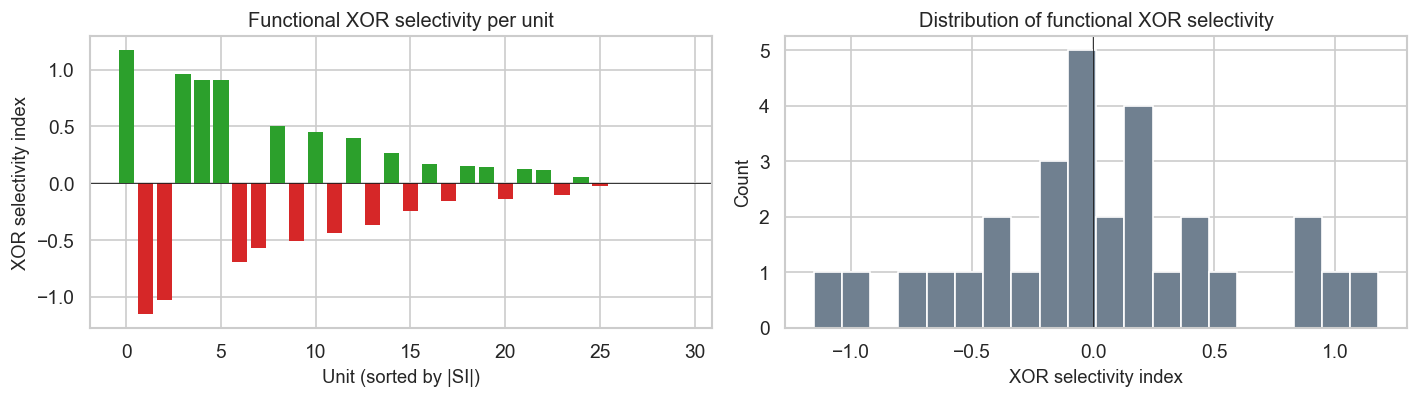

In [24]:
sorted_idx = np.argsort(np.abs(xor_si))[::-1].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

ax = axes[0]
colours_bar = [C_REWARD if xor_si[i] > 0 else C_NOREWARD for i in sorted_idx]
ax.bar(range(len(xor_si)), xor_si[sorted_idx], color=colours_bar, edgecolor='none')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Unit (sorted by |SI|)')
ax.set_ylabel('XOR selectivity index')
ax.set_title('Functional XOR selectivity per unit')

ax = axes[1]
ax.hist(xor_si, bins=20, color='slategray', edgecolor='white')
ax.axvline(0, color='k', lw=0.5)
ax.set_xlabel('XOR selectivity index')
ax.set_ylabel('Count')
ax.set_title('Distribution of functional XOR selectivity')

plt.tight_layout()
plt.show()


In [36]:
# ── Mask top-k functionally XOR-selective units ─────────────────────
k = 28  # try changing this!

top_k_units = np.argsort(np.abs(xor_si))[::-1][:k].copy()
print(f'Masking {k} most functionally XOR-selective units: {top_k_units}')
print(f'  Their SI values: {xor_si[top_k_units]}')
print(f'  Zeroing their rows in W_in and rows+cols in W_hh, then re-running forward pass.')

activations_func_masked, acc_func = mask_units(model, top_k_units, X, y, mask)
print(f'  Accuracy after masking: {acc_func:.1%}')

# ── Re-decode ──────────────────────────────────────────────────────
scores_func_masked = {name: [] for name in var_names}
for t in range(n_timepoints):
    X_t = activations_func_masked[:, t, :]
    for name, vid in zip(var_names, var_ids):
        y_dec = assign_lables(trial_types, decoding_targets[vid, :])
        scores_func_masked[name].append(decode(X_t, y_dec))

for name in var_names:
    scores_func_masked[name] = np.array(scores_func_masked[name])


Masking 28 most functionally XOR-selective units: [ 5  6  2 19 12 16 11 26 28  4 29 20 17  7 10 14 18 15 23 27 13  8  1 22
 24  0 21  9]
  Their SI values: [ 1.1772838e+00 -1.1548728e+00 -1.0332900e+00  9.6331048e-01
  9.1073179e-01  9.0578687e-01 -6.9692457e-01 -5.7342845e-01
  5.0819564e-01 -5.0753242e-01  4.5530301e-01 -4.3548784e-01
  3.9623588e-01 -3.6711836e-01  2.7016830e-01 -2.4402463e-01
  1.7142963e-01 -1.5507555e-01  1.5111256e-01  1.4030504e-01
 -1.3550454e-01  1.2834960e-01  1.1758888e-01 -1.0712075e-01
  5.0390959e-02 -2.7454704e-02  4.8576999e-03 -2.6221971e-05]
  Zeroing their rows in W_in and rows+cols in W_hh, then re-running forward pass.
  Accuracy after masking: 50.0%


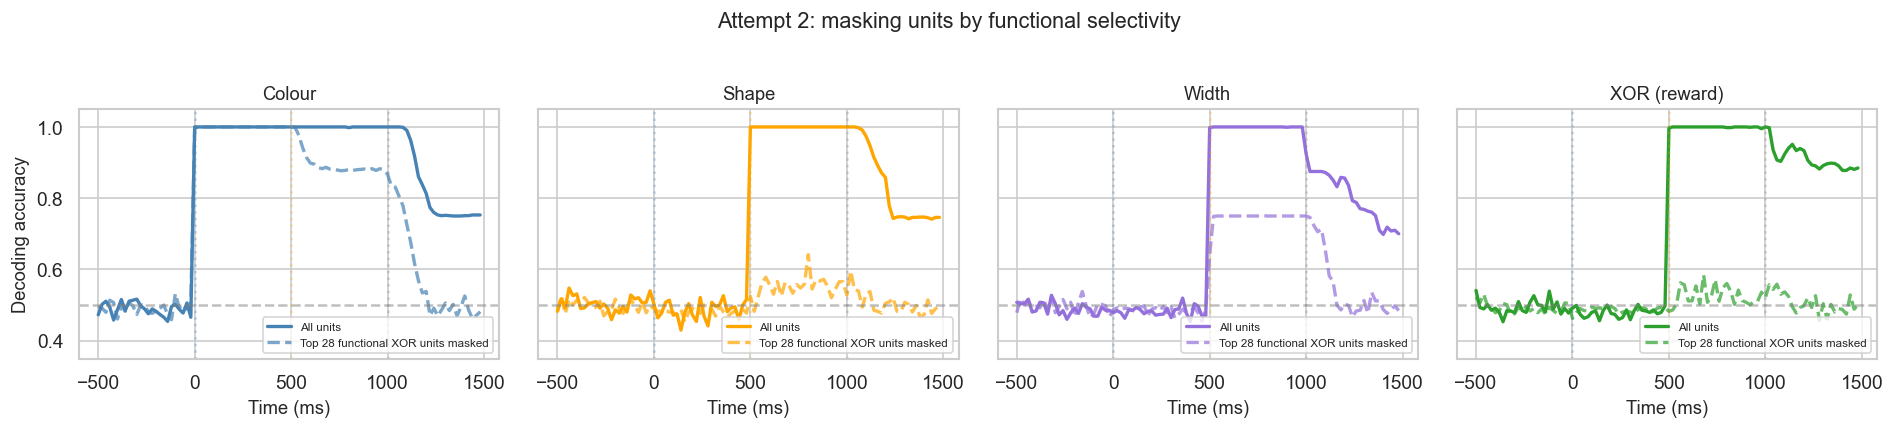

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, name, col in zip(axes, var_names, colours_var):
    ax.plot(times, scores[name], color=col, lw=2, label='All units')
    ax.plot(times, scores_func_masked[name], color=col, lw=2, ls='--',
            alpha=0.7, label=f'Top {k} functional XOR units masked')
    ax.axhline(0.5, color='gray', ls='--', alpha=0.5)
    ax.axvline(0, color='steelblue', ls=':', alpha=0.3)
    ax.axvline(500, color='orange', ls=':', alpha=0.3)
    ax.axvline(1000, color='gray', ls=':', alpha=0.3)
    ax.set_title(name, fontsize=11)
    ax.set_xlabel('Time (ms)')
    ax.set_ylim(0.35, 1.05)
    ax.legend(fontsize=7, loc='lower right')

axes[0].set_ylabel('Decoding accuracy')
plt.suptitle(f'Attempt 2: masking units by functional selectivity', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
### ★ Exercise: how distributed is the XOR representation?

Go back to the masking cell above and try different values of `k` (e.g. 1, 3, 5, 10, 15, 20). For each:

1. How much does XOR decoding drop?
2. At what `k` does XOR reach chance level (~50%)?
3. Do Colour and Shape decoding ever drop? If so, at what `k`?

What does this tell you about how "concentrated" vs "distributed" the XOR representation is in this random network?


---
## 5.4 Comparing the two approaches

The contrast between the two masking experiments reveals something fundamental about recurrent networks:

- **Structural masking** (Attempt 1) removed ~15 units — half the network — yet XOR decoding barely flinched. Connectivity alone does not determine what a unit represents.
- **Functional masking** (Attempt 2) removed just 5 units and substantially reduced XOR decoding. Yet even this is not enough to fully abolish it — you would need to mask close to 20 units (two-thirds of the network) to push XOR decoding to chance.

Why is the XOR signal so distributed? Because **nonlinear mixed selectivity is not a special property of a few units — it is a generic consequence of recurrent dynamics**. Every unit in the network receives, through the recurrent connections $W_{\text{hh}}$, a mixture of signals from other units. A unit that starts with pure Colour selectivity at its input can acquire Shape information through recurrence, and the ReLU nonlinearity turns this mixture into a conjunctive response. The result is that XOR-related information is spread across most of the network, not concentrated in a handful of "XOR neurons".

This is one of the key properties of recurrent neural networks: even without training, the recurrent mixing of variables through nonlinear dynamics produces representations that support simple cognitive operations like XOR. There will almost always be units that happen to mix the right variables in the right way.

> 💡 **Key takeaway**: Nonlinear mixed selectivity in an RNN is not just about feedforward input weights — it emerges from the interplay of recurrent connectivity and nonlinear activation. This is why recurrent networks are powerful function approximators even at initialisation, and why training can refine — rather than create from scratch — the representations needed for a task.
